# Photon Subtraction in Graph State
2026\. 05\. 19.  Make the pseudo code

## 1. Set the graph state

##### Initial parameters, modules and functions

In [61]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
# Graph: paper-style 6-node graph, labels 1-6 1-2-(3,4)-5-6 graph
Adj = np.array([[0, 1],
                [1, 0],
                ], dtype=float)
m = Adj.shape[0]

# Phase-space convention: q = (x1, ..., xm, p1, ..., pm)
I_m = np.eye(m)
Z_m = np.zeros((m, m))
Omega = np.block([[Z_m, I_m], [-I_m, Z_m]]) # [0, I; -I, 0] symplectic form
J = Omega.T # [0, -I; I, 0] symplectic form in Mattia's convention

# CZ symplectic matrix
G = np.block([[I_m, Z_m], [Adj, I_m]])

# Input covariance, paper convention: vacuum variance = 1
squeezing_db = np.full(m,10, dtype=float) # 단위는 dB 
#squeezing_db = np.array([3, 4, 12, 5, 3, 5], dtype=float) # mode별로 squeezing 다르게 주는 경우

s = 1 ** (squeezing_db / 10) # 단위 변환
V0 = np.diag(np.concatenate([s, 1 / s])) # diag(s_1, ..., s_m, 1/s_1, ..., 1/s_m)


# Graph-state covariance
V = G @ V0 @ G.T # maybe later we adjust this code to general mixed case.

# Photon-subtraction mode
# annhilation operator 기준으로 photon subtraction을 설명하기 위한 f이다. 복소수가 가능하며 C^(m)이다.
# a(f) = f1 a1 + f2 a2 + ... + fm am 이다.

f_sub = np.array([1, 0], dtype=complex) # a(f_sub) = sum f_sub[i] a_i
f_sub = f_sub / np.linalg.norm(f_sub) # 정규화

# mattia convention으로 표현, g_sub이 전부 실수 R^(2m)이다. -> 이는 quadrature 기준으로 중첩을 설명하기 위한 convention이다.
# 수식적으로는 g = (Re(f), -Im(f))^T)이고, Q(g) = x(g), Q(Jg) = p(g)이다.

g_sub = np.concatenate([np.real(f_sub), -np.imag(f_sub)]) # g_sub = (Re(f_sub), -Im(f_sub)) in phase space , a(f_sub) = 1/2 (Q(g_sub)+iQ(Jg_sub)) 
Jg_sub = J @ g_sub
Pi_g = np.outer(g_sub, g_sub) + np.outer(Jg_sub, Jg_sub) # Πg =ggT + Jg(Jg)T , projection matrix for the subtracted mode

sub_node = 1
sub_label = rf"$g=e_{{{sub_node}}}$"

##### graph plotting function

In [62]:
from matplotlib.colors import LinearSegmentedColormap

blue = LinearSegmentedColormap.from_list(
    "blue",
    ["#3f5f87", "#7b8a70", "#fffbe6"]
)

red = LinearSegmentedColormap.from_list(
    "red",
    ["#18051f", "#5b2a86", "#d44a1c", "#ffc247", "#fffbe6"]
)

In [63]:
def plot_graph_from_matrix(
    W,
    node_values=None,
    title="",
    threshold=1e-6,
    pos=None,
    cmap=blue,
    vmin=None,
    vmax=None,
    colorbar_label="",
    draw_labels=None,
    labels=None
):
    """
    W: weighted adjacency matrix 
    node_values: optional node color values, e.g. kurtosis, purity, nullifier_var
    """

    W_plot = np.array(W, dtype=float).copy()
    G_plot = nx.from_numpy_array(W_plot)

    # automatic layout - 어느정도 정렬된 그래프를 그려준다. 더 깔끔하게 그리고 싶을때는 pos를 직접 지정
    if pos is None:
        pos = nx.kamada_kawai_layout(G_plot)


    # label이 주어지지 않으면 기본적으로 1부터 시작
    if labels is None:
        labels = {i: i + 1 for i in range(W_plot.shape[0])}

    # node_values가 있으면 논문 figure처럼 label을 기본적으로 끔
    if draw_labels is None:
        draw_labels = node_values is None

    # plotting // 사이즈 고정
    plt.figure(figsize=(4.2, 3.2), dpi=180)
    
    
    # graph edge(선) 그리기
    nx.draw_networkx_edges(
        G_plot,
        pos,
        edge_color="#5b668a",
        width=1.4,
        alpha=0.75
    )

    # graph node(노드) 그리기
    if node_values is None:
        nx.draw_networkx_nodes(
            G_plot,
            pos,
            node_color="white",
            edgecolors="black",
            linewidths=1.1,
            node_size=700
        )

    else:
        node_values_plot = np.asarray(node_values, dtype=float)

        # colorbar range를 node_values에서 자동 설정
        if vmin is None:
            vmin = np.nanmin(node_values_plot)
        if vmax is None:
            vmax = np.nanmax(node_values_plot)

        # 모든 node value가 같은 경우 colorbar error 방지
        if np.isclose(vmin, vmax):
            vmin -= 1e-9
            vmax += 1e-9

        nodes = nx.draw_networkx_nodes(
            G_plot,
            pos,
            node_color=node_values_plot,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            edgecolors="#444444",
            linewidths=1.1,
            node_size=500
        )

        cbar = plt.colorbar(nodes, fraction=0.045, pad=0.03)
        if colorbar_label:
            cbar.set_label(colorbar_label, fontsize=9)
        cbar.ax.tick_params(labelsize=8)

    # graph label 그리기
    if draw_labels:
        nx.draw_networkx_labels(
            G_plot,
            pos,
            labels=labels,
            font_color="black",
            font_size=9
        )

    plt.title(title, fontsize=10, pad=6)
    plt.axis("equal")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    return pos

##### matrix visualization function

In [64]:
def show_mat(M, name="M", digits=3, tol=1e-10):
    M_show = np.array(M, dtype=float).copy()
    M_show[np.abs(M_show) < tol] = 0

    n, m = M_show.shape
    df = pd.DataFrame(
        M_show,
        index=[f"{i+1}" for i in range(n)],
        columns=[f"{j+1}" for j in range(m)]
    )

    print(name)
    display(df.style.format(f"{{:.{digits}f}}"))

In [65]:
def draw_mat(M, title="", cmap="bwr", label=False, digits=2,
             vlim=None, figsize=(5, 4.5), grid=False):
    M = np.asarray(M)
    n, m = M.shape

    vmax = np.percentile(np.abs(M), 95) if vlim is None else vlim
    vmax = vmax if vmax > 0 else 1

    fig, ax = plt.subplots(figsize=figsize, dpi=180)
    im = ax.imshow(
        M,
        cmap=cmap,
        vmin=-vmax,
        vmax=vmax,
        interpolation="nearest",
        aspect="equal"
    )

    ax.set_xticks(range(m), labels=range(1, m + 1))
    ax.set_yticks(range(n), labels=range(1, n + 1))
    ax.tick_params(
        top=True, labeltop=True,
        bottom=False, labelbottom=False,
        labelsize=8
    )

    # grid for every matrix cell
    if grid:
        ax.set_xticks(np.arange(-0.5, m, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
        ax.grid(which="minor", color="k", linewidth=0.18, alpha=0.15)
        ax.tick_params(which="minor", bottom=False, left=False)

    if label:
        for i in range(n):
            for j in range(m):
                ax.text(
                    j, i, f"{M[i, j]:.{digits}f}",
                    ha="center", va="center", fontsize=6
                )

    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

In [66]:
from matplotlib.colors import TwoSlopeNorm, PowerNorm
import numpy as np
import matplotlib.pyplot as plt

def draw_phase_matrix(
    M,
    title="",
    mode_labels=None,
    cmap="Reds",
    positive=True,
    vlim=None,
    gamma=1.5,
    tick_step=1,
    figsize=(5, 4.5),
    grid=True,
):
    """
    M: 2m x 2m phase-space matrix
       ordering = (x1,...,xm,p1,...,pm)

    positive=True:
        use Reds colormap with PowerNorm.
        Good when A_minus is nonnegative or mostly positive.

    positive=False:
        use diverging colormap centered at 0.
        Good when positive/negative values both matter.
    """

    M = np.asarray(M, dtype=float)
    N = M.shape[0]
    assert M.shape[0] == M.shape[1], "M must be square."
    assert N % 2 == 0, "M must be 2m x 2m."

    m = N // 2

    if mode_labels is None:
        mode_labels = np.arange(1, m + 1)

    labels = (
        [rf"$x_{{{i}}}$" for i in mode_labels]
        + [rf"$p_{{{i}}}$" for i in mode_labels]
    )

    fig, ax = plt.subplots(figsize=figsize, dpi=170)

    if positive:
        vmax = np.nanmax(M) if vlim is None else vlim
        vmax = vmax if vmax > 0 else 1
        norm = PowerNorm(gamma=gamma, vmin=0, vmax=vmax)
        im = ax.imshow(
            M,
            cmap=cmap,
            norm=norm,
            interpolation="nearest",
            aspect="equal"
        )
    else:
        vmax = np.nanpercentile(np.abs(M), 99) if vlim is None else vlim
        vmax = vmax if vmax > 0 else 1
        norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
        im = ax.imshow(
            M,
            cmap=cmap,
            norm=norm,
            interpolation="nearest",
            aspect="equal"
        )

    # tick labels
    ticks = np.arange(0, N, tick_step)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)

    if tick_step == 1 and N <= 30:
        ax.set_xticklabels([labels[i] for i in ticks], fontsize=8)
        ax.set_yticklabels([labels[i] for i in ticks], fontsize=8)
    else:
        ax.set_xticklabels(ticks + 1, fontsize=8)
        ax.set_yticklabels(ticks + 1, fontsize=8)

    ax.tick_params(        
        top=True,
        labeltop=True,
        bottom=False,
        labelbottom=False,
        length=3
    )

    # cell grid
    if grid:
        ax.set_xticks(np.arange(-0.5, N, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, N, 1), minor=True)
        ax.grid(which="minor", color="k", linewidth=0.18, alpha=0.12)
        ax.tick_params(which="minor", bottom=False, left=False)

    # x/p block separator
    ax.axhline(m - 0.5, color="k", linewidth=1.0, alpha=0.55)
    ax.axvline(m - 0.5, color="k", linewidth=1.0, alpha=0.55)

    ax.set_title(title, fontsize=13, pad=8)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=9)

    plt.tight_layout()
    plt.show()


##### Graph-State Sanity

In [67]:
print("m =", m)

print("Adj =\n", Adj)
print("V =\n", V)

print("f_sub =", f_sub)
print("f_sub shape =", f_sub.shape)

eigvals_physical = np.linalg.eigvalsh(V + 1j * Omega)
print("physical covariance(V + iOmega):", np.min(eigvals_physical) >= -1e-10)
#print("min eigenvalue of V + iOmega =", np.min(eigvals_physical))

m = 2
Adj =
 [[0. 1.]
 [1. 0.]]
V =
 [[1. 0. 0. 1.]
 [0. 1. 1. 0.]
 [0. 1. 2. 0.]
 [1. 0. 0. 2.]]
f_sub = [1.+0.j 0.+0.j]
f_sub shape = (2,)
physical covariance(V + iOmega): True


chosen: x - Γp
nullifier variances = [0.5 0.5]
below vacuum: [ True  True]
Adj_eff =
 [[0.  0.5]
 [0.5 0. ]]


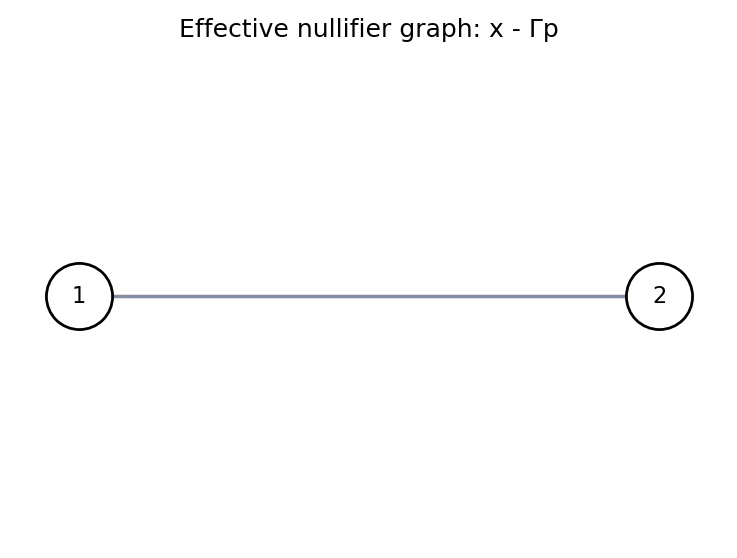

In [68]:
# Effective nullifier graph from V
V_xx = V[:m, :m]
V_xp = V[:m, m:]
V_px = V[m:, :m]
V_pp = V[m:, m:]

# nullfier 1 -> delta1 = p - Gamma1 x 꼴인 경우
Gamma1 = V_px @ np.linalg.pinv(V_xx)
Vd1 = V_pp - Gamma1 @ V_xp - V_px @ Gamma1.T + Gamma1 @ V_xx @ Gamma1.T


# nullfier 2 -> delta2 = x - Gamma2 p 꼴인 경우
Gamma2 = V_xp @ np.linalg.pinv(V_pp)
Vd2 = V_xx - Gamma2 @ V_px - V_xp @ Gamma2.T + Gamma2 @ V_pp @ Gamma2.T

# choose better nullifier
if np.trace(Vd1) <= np.trace(Vd2):
    Gamma_eff = Gamma1
    V_delta = Vd1
    nullifier_type = "p - Γx"
else:
    Gamma_eff = Gamma2
    V_delta = Vd2
    nullifier_type = "x - Γp"

nullifier_var = np.diag(V_delta)




print("chosen:", nullifier_type)
# nullifier variances 출력
print("nullifier variances =", nullifier_var)

# check nullifier variances below vacuum
print("below vacuum:", nullifier_var < 1)

# 해당 nullifer variances로 나온 effective adjacency matrix 출력
print("Adj_eff =\n", Gamma_eff)


# plot the graph using the graph plotting function defined above 
# plot_graph_from_matrix (W=Gamma_eff, node_values=kurtosis같은 노드별 값(기본은 none), title=f"(제목)", pos=pos(기본은 none))
pos = plot_graph_from_matrix(
    Gamma_eff,
    node_values=None,
    title=f"Effective nullifier graph: {nullifier_type}",
    pos=  
    {
    0: (0.0, 0.0),
    1: (1.5, 0.0),
    2: (2.75, 0.9),
    3: (2.75, -0.9),
    4: (4.0, 0.0),
    5: (5.5, 0.0),
    }
)

## 2. Photon Subtraction on the graph

##### A Matrix for Photon Subtraction

Pi_g projector check: True
A_minus symmetric check: True
A_minus = 


,1,2,3,4
1,0.000,0.000,0.000,0.000
2,0.000,2.000,2.000,0.000
3,0.000,2.000,2.000,0.000
4,0.000,0.000,0.000,2.000


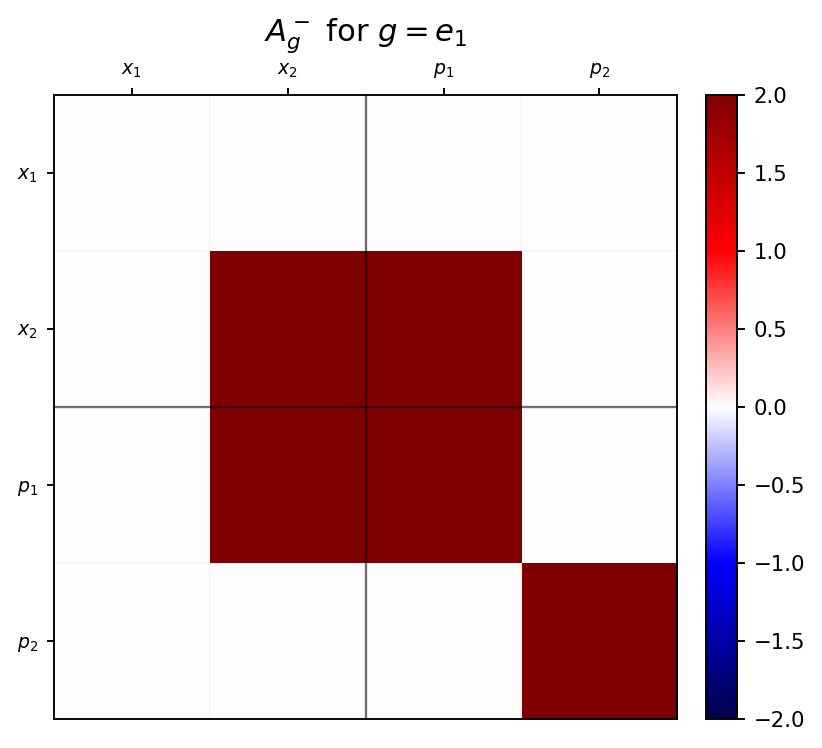

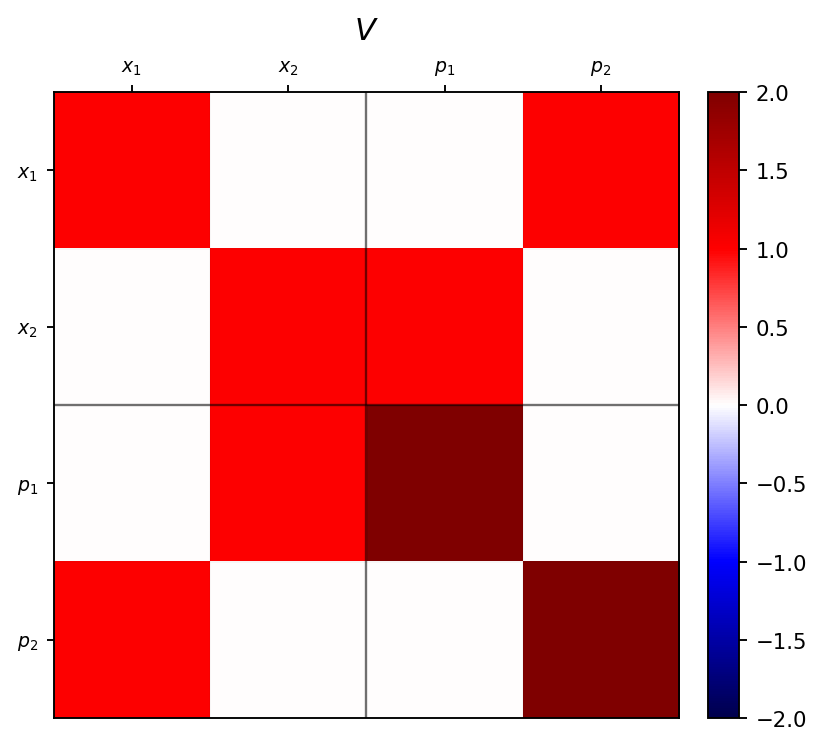

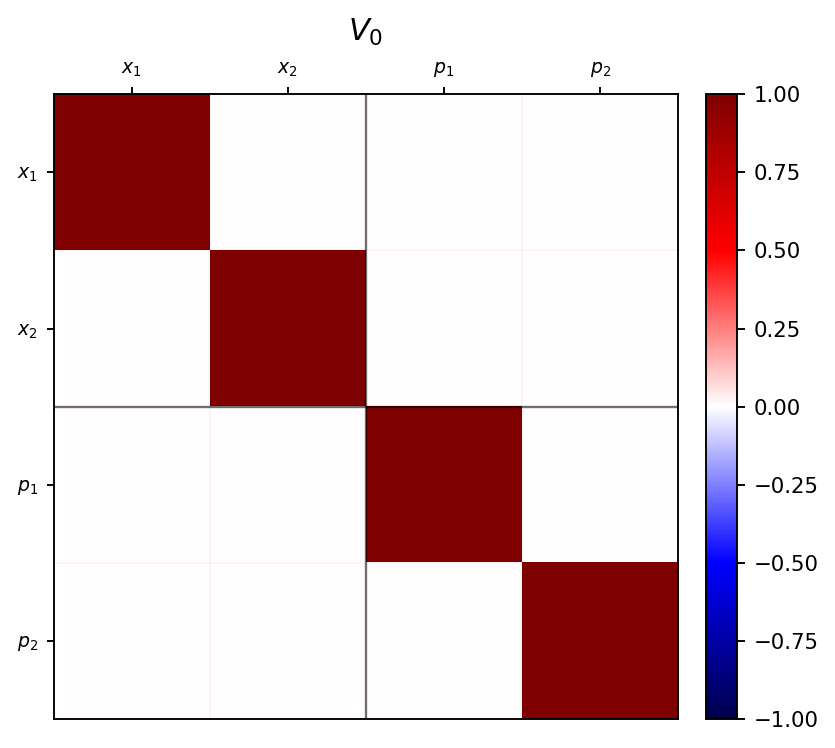

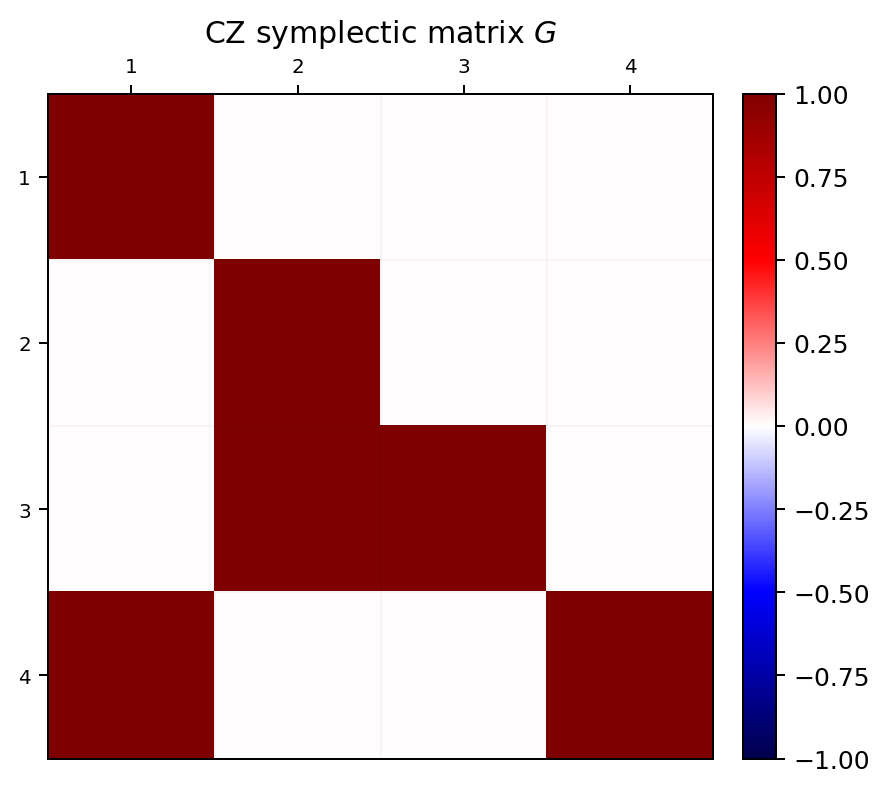

In [69]:
# A_minus matrix
# A_minus = 2 (V - I) Πg (V - I) / Tr[(V - I) Πg]

I_2m = np.eye(2 * m) # 2m x 2m identity matrix, m은 모드 수

denom = np.trace((V - I_2m) @ Pi_g) # 분모 계산, Tr[(V - I) Πg] , 이거의 4배값이 photon subtraction의 성공확률

# print("denom =", denom)
# 예외처리
if np.isclose(denom, 0):
    raise ValueError("denom is close to zero: photon subtraction mode may be vacuum-like.")

A_minus = 2 * (V - I_2m) @ Pi_g @ (V - I_2m) / denom

print("Pi_g projector check:", bool(np.linalg.norm(Pi_g @ Pi_g - Pi_g))<1e-10)
print("A_minus symmetric check:", bool(np.linalg.norm(A_minus - A_minus.T) < 1e-10))
#print("A_minus =\n", A_minus)
show_mat(A_minus, name="A_minus = ")

#draw_mat(A_minus, r"$A_g^-$")
draw_phase_matrix(
    A_minus,
    title = rf"$A_g^-$ for {sub_label}",
    positive=False,
    cmap="seismic",
    tick_step=1,
    figsize=(5, 4.5),
    grid=True
)
draw_phase_matrix(
    V,
    title=r"$V$",
    positive=False,
    cmap="seismic",
    tick_step=1,
    figsize=(5, 4.5),
    grid=True
)
draw_phase_matrix(
    V0,
    title=r"$V_0$",
    positive=False,
    cmap="seismic",
    tick_step=1,
    figsize=(5, 4.5),
    grid=True
)
draw_mat(G, title=r"CZ symplectic matrix $G$", cmap="seismic", label=False, digits=1,grid=True)

v_p = [2. 2.]
a_p = [2. 2.]
K_ex_p = [-0.75 -0.75]


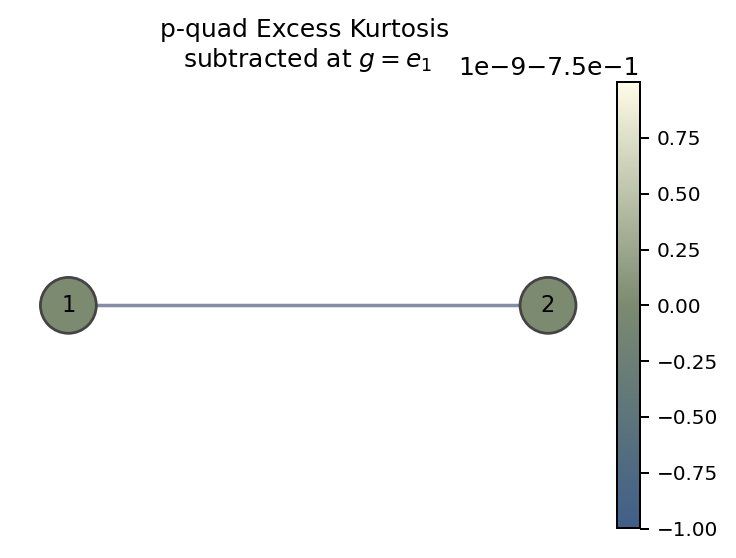

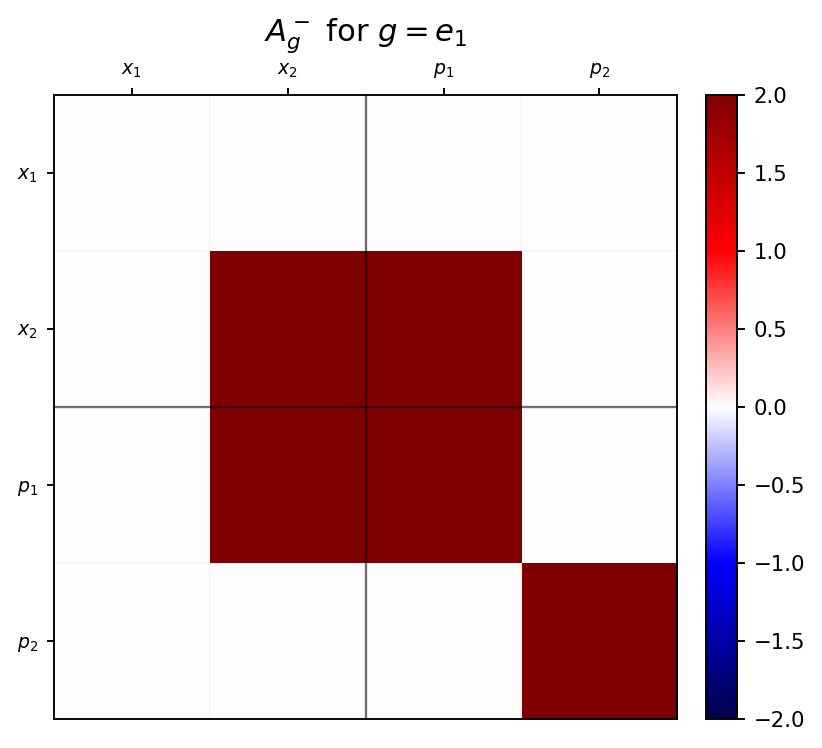

v_x = [1. 1.]
a_x = [0. 2.]
K_ex_x = [-0.         -1.33333333]


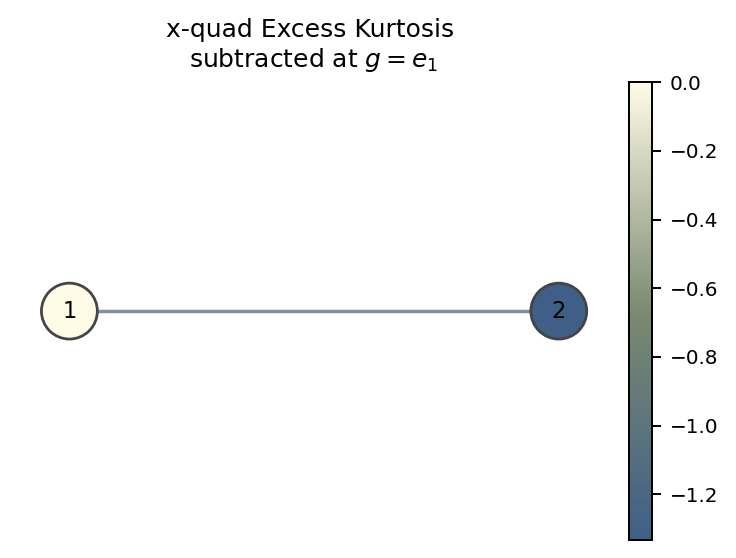

In [70]:
# Node-wise p-quadrature excess kurtosis

p_indices = np.arange(m, 2 * m) # p-quadrature는 phase space 벡터의 뒤쪽 m개 요소에 해당하므로, 인덱스가 m부터 2m-1까지인 부분을 선택

v_p = np.diag(V)[p_indices] # photon subtraction 전의 p-quadrature variance, V 행렬의 뒤쪽 m개 대각 원소에 해당
a_p = np.diag(A_minus)[p_indices] # photon subtraction으로 인한 p-quadrature variance 변화량, A_minus 행렬의 뒤쪽 m개 대각 원소에 해당

K_ex_p = -3 * (a_p ** 2) / ((v_p + a_p) ** 2) # <Q(f)^k>_T를 통해 excess kurtosis p-quadrature 계산, 

print("v_p =", v_p)
print("a_p =", a_p)
print("K_ex_p =", K_ex_p)

pos = plot_graph_from_matrix(
    Gamma_eff,
    node_values=K_ex_p,
    title=f"p-quad Excess Kurtosis \nsubtracted at {sub_label}",
    pos=pos,
    draw_labels=True
)
draw_phase_matrix(
    A_minus,
    title = rf"$A_g^-$ for {sub_label}",
    positive=False,
    cmap="seismic",
    tick_step=1,
    figsize=(5, 4.5),
    grid=True
)

# Node-wise x-quadrature excess kurtosis

x_indices = np.arange(0, m) # x-quadrature는 phase space 벡터의 앞쪽 m개 요소에 해당하므로, 인덱스가 0부터 m-1까지인 부분을 선택

v_x = np.diag(V)[x_indices] # photon subtraction 전의 x-quadrature variance, V 행렬의 앞쪽 m개 대각 원소에 해당
a_x = np.diag(A_minus)[x_indices] # photon subtraction으로 인한 x

K_ex_x = -3 * (a_x ** 2) / ((v_x + a_x) ** 2) # <Q(f)^k>_T를 통해 excess kurtosis x-quadrature 계산,

print("v_x =", v_x)
print("a_x =", a_x)
print("K_ex_x =", K_ex_x)

pos = plot_graph_from_matrix(
    Gamma_eff,
    node_values=K_ex_x,
    title=f"x-quad Excess Kurtosis \nsubtracted at {sub_label}",
    pos=pos,
    draw_labels=True
)

##### Additional Analysis - Wigner negativity

In [71]:
def reduced_matrices(V, A, subset, m):
    """
    V, A: full 2m x 2m matrices
    subset: list of mode indices,
            e.g. [1] for node 1, [1, 3, 6] for nodes 1,3,6
    m: number of modes
    """
    subset = np.array(subset, dtype=int)-1

    inds = np.concatenate([subset, m + subset])

    V_sub = V[np.ix_(inds, inds)]
    A_sub = A[np.ix_(inds, inds)]

    return V_sub, A_sub, inds

In [72]:
V_k, A_k, inds = reduced_matrices(V, A_minus, subset=[1], m=m) # node 1에 해당하는 mode만 남긴 reduced matrix, subset=[1]은 node 1을 의미, m은 전체 모드 수

show_mat(V_k)
show_mat(A_k)

M


,1,2
1,1.000,0.000
2,0.000,2.000


M


,1,2
1,0.000,0.000
2,0.000,2.000


In [73]:
def nodewise_negativity_quantities(V, A, m):
    N_vals = np.zeros(m)   # N_k = Tr(V_k^{-1} A_k)
    W0_vals = np.zeros(m)  # W_k(0)

    for k in range(1, m + 1):   # 1-indexed node label
        V_k, A_k, _ = reduced_matrices(V, A, [k], m)

        N_k = np.trace(np.linalg.inv(V_k) @ A_k)
        W0_k = (2 - N_k) / (2 * (2 * np.pi) * np.sqrt(np.linalg.det(V_k)))

        N_vals[k - 1] = N_k
        W0_vals[k - 1] = W0_k

    return N_vals, W0_vals

min W0_vals = -0.05626976975981913


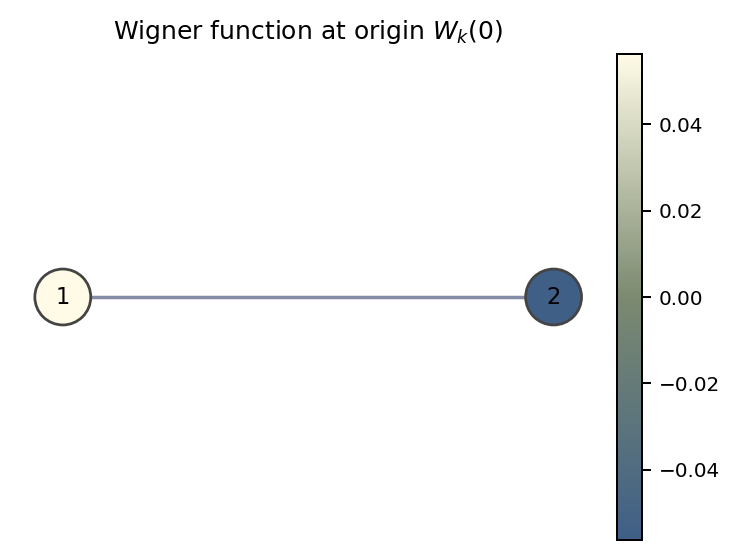

In [74]:
N_vals, W0_vals = nodewise_negativity_quantities(V, A_minus, m)

#print("N_vals =", N_vals)
#print("W0_vals =", W0_vals)
print("min W0_vals =", np.min(W0_vals))
# plot_graph_from_matrix(
#     Adj,
#     node_values=W0_vals,
#     title="Wigner function at origin $W_k(0)$",
#     pos=pos,
#     cmap="nipy_spectral", 
#     vmin=np.min(W0_vals),
#     draw_labels=True
# )



pos = plot_graph_from_matrix(
    Adj,
    node_values=W0_vals,
    title="Wigner function at origin $W_k(0)$",
    pos=pos,
    draw_labels=True
)

In [75]:
def nodewise_gaussian_wigner_origin(V, m):
    WG0 = np.zeros(m)

    for k in range(1, m + 1):
        V_k, _, _ = reduced_matrices(V, np.zeros_like(V), subset=[k], m=m)
        WG0[k - 1] = 1 / ((2 * np.pi) * np.sqrt(np.linalg.det(V_k)))

    return WG0

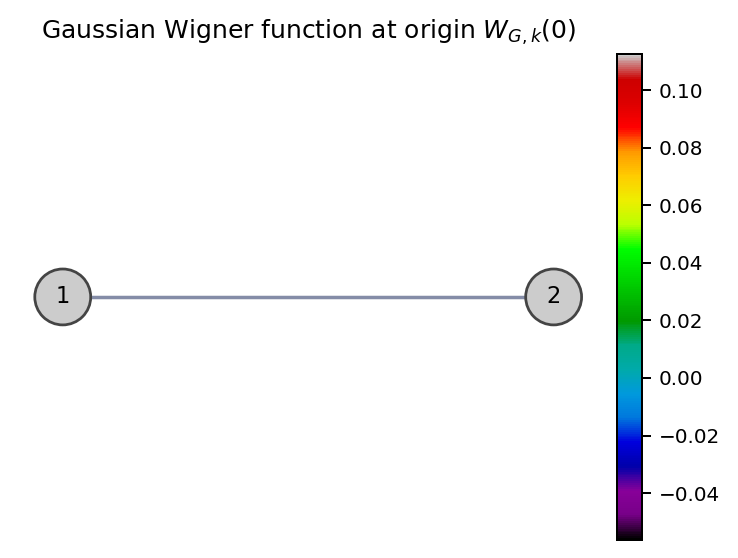

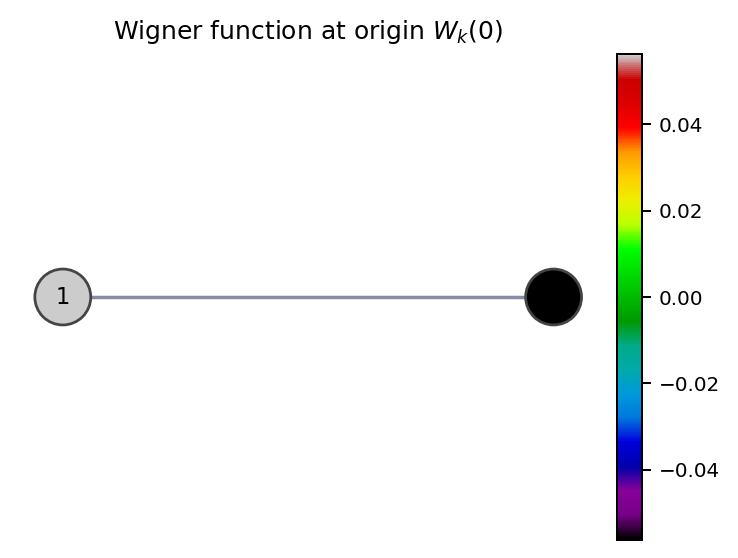

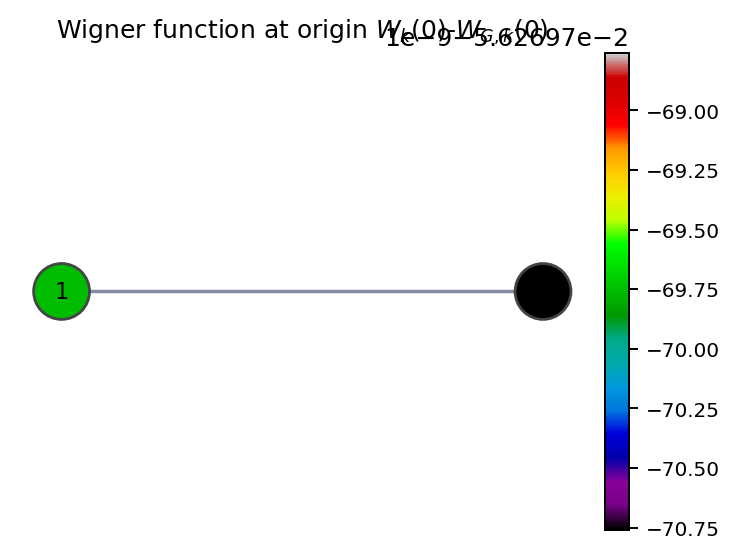

{0: (0.0, 0.0),
 1: (1.5, 0.0),
 2: (2.75, 0.9),
 3: (2.75, -0.9),
 4: (4.0, 0.0),
 5: (5.5, 0.0)}

In [76]:
WG0_vals = nodewise_gaussian_wigner_origin(V, m)

pos = plot_graph_from_matrix(
    Adj,
    node_values=WG0_vals,
    cmap="nipy_spectral",
    pos=pos,
    draw_labels=True,
    vmin=np.min(W0_vals),
    title=r"Gaussian Wigner function at origin $W_{G,k}(0)$"
)
plot_graph_from_matrix(
    Adj,
    node_values=W0_vals,
    title="Wigner function at origin $W_k(0)$",
    pos=pos,
    cmap="nipy_spectral", 
    vmin=np.min(W0_vals),
    draw_labels=True
)
plot_graph_from_matrix(
    Adj,
    node_values=W0_vals-WG0_vals,
    title="Wigner function at origin $W_k(0)$-$W_{G,k}(0)$",
    pos=pos,
    cmap="nipy_spectral", 
    vmin=np.min(W0_vals),
    draw_labels=True
)

In [77]:
#here!
# Common Wigner plotting utilities.
# Run this cell once, then use the output cell below.

from matplotlib.colors import Normalize, TwoSlopeNorm
import plotly.graph_objects as go
from plotly.subplots import make_subplots


def gaussian_wigner_grid(V_k, xlim=10, n=100):
    x = np.linspace(-xlim, xlim, n)
    p = np.linspace(-xlim, xlim, n)
    X, P = np.meshgrid(x, p)
    R = np.stack([X, P], axis=-1)

    V_inv = np.linalg.inv(V_k)
    det_V = np.linalg.det(V_k)
    quad = np.einsum("...i,ij,...j->...", R, V_inv, R)
    W = np.exp(-0.5 * quad) / ((2 * np.pi) * np.sqrt(det_V))

    return X, P, W


def photon_subtracted_wigner_grid(V_k, A_k, xlim=10, n=100):
    X, P, W_gauss = gaussian_wigner_grid(V_k, xlim=xlim, n=n)
    R = np.stack([X, P], axis=-1)

    V_inv = np.linalg.inv(V_k)
    B = V_inv @ A_k @ V_inv
    quad_A = np.einsum("...i,ij,...j->...", R, B, R)
    trace_A = np.trace(V_inv @ A_k)
    W_minus = 0.5 * (quad_A - trace_A + 2) * W_gauss

    return X, P, W_minus


def node_wigner_data(V, A, node, m, xlim=10, n=100):
    V_k, A_k, _ = reduced_matrices(V, A, subset=[node], m=m)
    X, P, W_before = gaussian_wigner_grid(V_k, xlim=xlim, n=n)
    _, _, W_after = photon_subtracted_wigner_grid(V_k, A_k, xlim=xlim, n=n)

    z_min = min(np.min(W_before), np.min(W_after))
    z_max = max(np.max(W_before), np.max(W_after))
    z_pad = 0.05 * (z_max - z_min) if not np.isclose(z_min, z_max) else 1e-3
    zlim = (z_min - z_pad, z_max + z_pad)

    return X, P, W_before, W_after, zlim


def wigner_color_norm(W):
    w_min = np.min(W)
    w_max = np.max(W)

    if w_min < 0 < w_max:
        return TwoSlopeNorm(vmin=w_min, vcenter=0, vmax=w_max)

    return Normalize(vmin=w_min, vmax=w_max)


def plot_wigner_surface_static(ax, X, P, W, title, cmap="inferno", zlim=None, zero_plane=True):
    norm = wigner_color_norm(W)
    ax.plot_surface(X, P, W, cmap=cmap, norm=norm, linewidth=0, antialiased=True)

    if zero_plane and zlim is not None and zlim[0] < 0 < zlim[1]:
        Z0 = np.zeros_like(W)
        ax.plot_surface(X, P, Z0, color="black", alpha=0.12, linewidth=0, shade=False)
        ax.contour(X, P, W, levels=[0], zdir="z", offset=0, colors="black", linewidths=1.1)

    ax.contour(X, P, W, zdir="z", offset=np.min(W), cmap=cmap, linewidths=0.7)
    ax.set_title(f"{title}\nmin={np.min(W):.3g}, max={np.max(W):.3g}")
    ax.set_xlabel("x")
    ax.set_ylabel("p")
    ax.set_zlabel("W")
    ax.view_init(elev=24, azim=-38)

    if zlim is not None:
        ax.set_zlim(*zlim)


def plot_node_wigner_3d_static(V, A, node, m, xlim=10, n=100, cmap_before="viridis", cmap_after="coolwarm"):
    X, P, W_before, W_after, zlim = node_wigner_data(V, A, node, m, xlim=xlim, n=n)

    fig = plt.figure(figsize=(14, 5.2))
    ax1 = fig.add_subplot(1, 2, 1, projection="3d")
    ax2 = fig.add_subplot(1, 2, 2, projection="3d")

    plot_wigner_surface_static(ax1, X, P, W_before, f"node {node}: before subtraction", cmap=cmap_before, zlim=zlim, zero_plane=False)
    plot_wigner_surface_static(ax2, X, P, W_after, f"node {node}: after subtraction", cmap=cmap_after, zlim=zlim)

    fig.subplots_adjust(left=0.02, right=0.98, bottom=0.02, top=0.88, wspace=0.04)
    plt.show()


def plot_node_wigner_3d_interactive(V, A, node, m, xlim=10, n=100):
    X, P, W_before, W_after, _ = node_wigner_data(V, A, node, m, xlim=xlim, n=n)

    after_abs = max(abs(np.min(W_after)), abs(np.max(W_after)))
    if np.isclose(after_abs, 0):
        after_abs = 1

    fig = make_subplots(
        rows=1,
        cols=2,
        specs=[[{"type": "surface"}, {"type": "surface"}]],
        subplot_titles=(
            f"node {node}: before subtraction<br>min={np.min(W_before):.3g}, max={np.max(W_before):.3g}",
            f"node {node}: after subtraction<br>min={np.min(W_after):.3g}, max={np.max(W_after):.3g}"
        ),
        horizontal_spacing=0.02
    )

    fig.add_trace(
        go.Surface(x=X, y=P, z=W_before, colorscale="Viridis", showscale=False),
        row=1,
        col=1
    )

    fig.add_trace(
        go.Surface(
            x=X,
            y=P,
            z=W_after,
            colorscale="RdBu_r",
            cmin=-after_abs,
            cmax=after_abs,
            showscale=True,
            colorbar=dict(title="W", x=1.02, len=0.75)
        ),
        row=1,
        col=2
    )

    fig.add_trace(
        go.Surface(
            x=X,
            y=P,
            z=np.zeros_like(W_after),
            surfacecolor=np.zeros_like(W_after),
            colorscale=[[0, "black"], [1, "black"]],
            opacity=0.18,
            showscale=False,
            hoverinfo="skip"
        ),
        row=1,
        col=2
    )

    camera = dict(eye=dict(x=0.8, y=1.8, z=0.8))
    scene_style = dict(
        xaxis_title="x",
        yaxis_title="p",
        zaxis_title="W",
        camera=camera,
        aspectmode="cube"
    )

    fig.update_layout(
        width=1150,
        height=560,
        margin=dict(l=0, r=0, t=60, b=0),
        scene=scene_style,
        scene2=scene_style
    )

    fig.show()


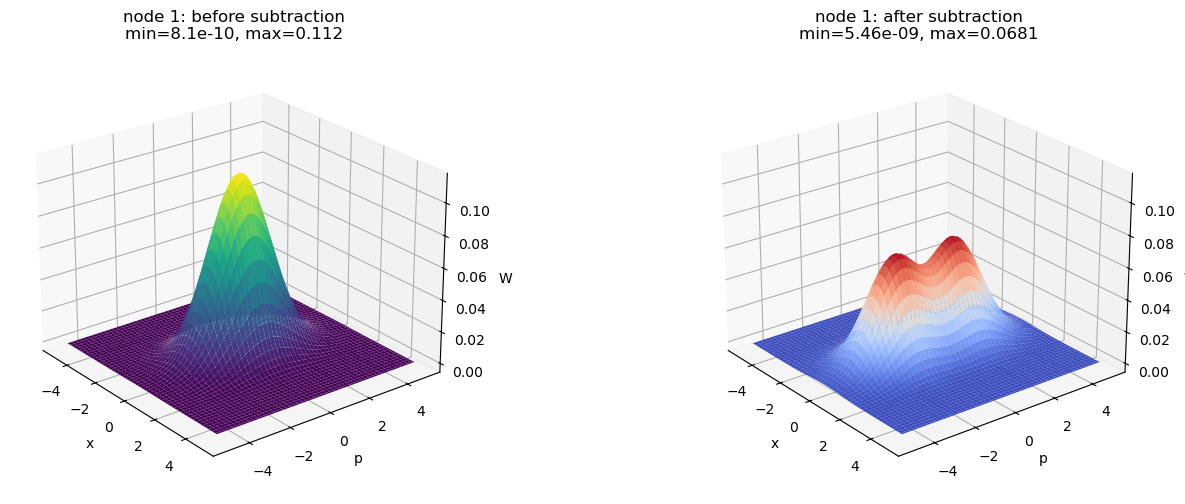

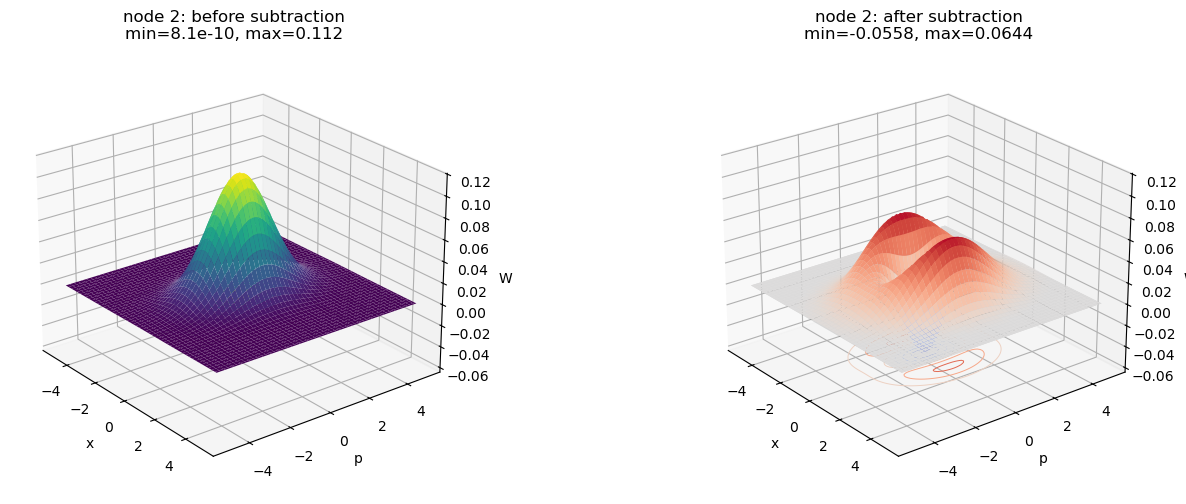

In [78]:
# plot the 3d single wigner function at each node
# Run the static version for lighter output. Turn on interactive only when you want mouse rotation.

nodes_to_plot = range(1, m + 1)
plot_static = True
plot_interactive = True

for node in nodes_to_plot:
    if plot_static:
        plot_node_wigner_3d_static(V, A_minus, node=node, m=m, xlim=5, n=100)

    if plot_interactive:
        plot_node_wigner_3d_interactive(V, A_minus, node=node, m=m, xlim=5, n=100)


## 3. Homodyne Measurement

####  3.1 Photon subtraction, and afterward, Neighborhood Deletion FeedFoward w/ x measurement(by HOMODYNE)

#####  Initial variable layer

In [79]:
# ============================================================
# 3.1.1 Initial variable layer
# Case a: photon subtraction 먼저 한 경우
# Corrected version: graph-nullifier feedforward
#
# IMPORTANT:
#   Use K_Gamma = [[0], [Gamma_RH]]
#   Do NOT use K_cm = V_qRxH V_xHxH^{-1}
#
# Existing variables:
#   m        : number of modes
#   V        : full Gaussian envelope matrix
#   A_minus  : full non-Gaussian correction matrix after photon subtraction
#   sub_node : photon-subtracted node label, 1-based
#   Gamma_eff or Adj : graph adjacency matrix
#
# ordering:
#   q = (x1,...,xm,p1,...,pm)
# ============================================================

import numpy as np

# ------------------------------------------------------------
# User input
# ------------------------------------------------------------
H = [2]          # deleted / homodyne-measured nodes, 1-based
j = sub_node           # photon-subtracted node, 1-based

# ------------------------------------------------------------
# Use already-defined A_minus
# ------------------------------------------------------------
A_j = A_minus

# ------------------------------------------------------------
# Choose graph adjacency matrix
# ------------------------------------------------------------
if "Gamma_eff" in globals():
    Gamma = Gamma_eff
elif "Adj" in globals():
    Gamma = Adj
else:
    raise NameError("Need graph adjacency matrix: Gamma_eff or Adj")

# ------------------------------------------------------------
# Convert to 0-based node indices
# ------------------------------------------------------------
H0 = np.array([h - 1 for h in H], dtype=int)
j0 = j - 1

R0 = np.array([n for n in range(m) if n not in H0], dtype=int)

r = len(R0)
h = len(H0)

print("H =", list(H0 + 1))
print("R =", list(R0 + 1))
print("photon-subtracted node j =", j)

# ------------------------------------------------------------
# Quadrature indices
# ordering: q = (x1,...,xm,p1,...,pm)
# ------------------------------------------------------------
xR_idx = R0
pR_idx = R0 + m
qR_idx = np.r_[xR_idx, pR_idx]

xH_idx = H0
pH_idx = H0 + m

# ------------------------------------------------------------
# Graph-nullifier feedforward gain
#
# Initial nullifier:
#   delta_R = p_R - Gamma_RR x_R - Gamma_RH x_H
#
# Feedforward:
#   p_R^ff = p_R - Gamma_RH x_H
#
# Therefore:
#   q_R^ff = q_R - K_Gamma x_H
#
# where:
#   K_Gamma = [ 0       ]
#             [ Gamma_RH]
# ------------------------------------------------------------
Gamma_RH = Gamma[np.ix_(R0, H0)]

K_Gamma = np.vstack([
    np.zeros((r, h)),
    Gamma_RH
])

print("Gamma_RH =")
print(Gamma_RH)
print("K_Gamma shape =", K_Gamma.shape)

# ------------------------------------------------------------
# Extract V blocks
# ------------------------------------------------------------
V_qRqR = V[np.ix_(qR_idx, qR_idx)]
V_qRxH = V[np.ix_(qR_idx, xH_idx)]
V_xHqR = V[np.ix_(xH_idx, qR_idx)]
V_xHxH = V[np.ix_(xH_idx, xH_idx)]

# ------------------------------------------------------------
# Correct Gaussian envelope after graph feedforward
#
# V_R_ff = L_Gamma V L_Gamma^T
#
# with
#   L_Gamma = ( I  -K_Gamma  0 )
#
# Block form:
#   V_R_ff
#   = V_qRqR
#     - K_Gamma V_xHqR
#     - V_qRxH K_Gamma^T
#     + K_Gamma V_xHxH K_Gamma^T
# ------------------------------------------------------------
V_R_ff = (
    V_qRqR
    - K_Gamma @ V_xHqR
    - V_qRxH @ K_Gamma.T
    + K_Gamma @ V_xHxH @ K_Gamma.T
)

V_R_ff = 0.5 * (V_R_ff + V_R_ff.T)

# ------------------------------------------------------------
# Extract A_minus blocks
# ------------------------------------------------------------
A_qRqR = A_j[np.ix_(qR_idx, qR_idx)]
A_qRxH = A_j[np.ix_(qR_idx, xH_idx)]
A_xHqR = A_j[np.ix_(xH_idx, qR_idx)]
A_xHxH = A_j[np.ix_(xH_idx, xH_idx)]

# ------------------------------------------------------------
# Correct non-Gaussian correction after graph feedforward
#
# A_R_ff = L_Gamma A_minus L_Gamma^T
# ------------------------------------------------------------
A_R_ff = (
    A_qRqR
    - K_Gamma @ A_xHqR
    - A_qRxH @ K_Gamma.T
    + K_Gamma @ A_xHxH @ K_Gamma.T
)

A_R_ff = 0.5 * (A_R_ff + A_R_ff.T)

# ------------------------------------------------------------
# Actual second moment of the final non-Gaussian state
# ------------------------------------------------------------
V_actual_R_ff = V_R_ff + A_R_ff

# ------------------------------------------------------------
# Target node local index
# If photon-subtracted node is deleted, j_local is None.
# ------------------------------------------------------------
if j0 in R0:
    j_local = int(np.where(R0 == j0)[0][0])
    print("target node remains.")
    print("target original node =", j)
    print("target local node =", j_local + 1)
else:
    j_local = None
    print("target photon-subtracted node is deleted.")

# ------------------------------------------------------------
# Checks
# ------------------------------------------------------------
print("V_R_ff shape =", V_R_ff.shape)
print("A_R_ff shape =", A_R_ff.shape)
print("V_actual_R_ff shape =", V_actual_R_ff.shape)

print("V_R_ff symmetric check:",
      bool(np.linalg.norm(V_R_ff - V_R_ff.T) < 1e-10))

print("A_R_ff symmetric check:",
      bool(np.linalg.norm(A_R_ff - A_R_ff.T) < 1e-10))

print("V_actual_R_ff symmetric check:",
      bool(np.linalg.norm(V_actual_R_ff - V_actual_R_ff.T) < 1e-10))

H = [2]
R = [1]
photon-subtracted node j = 1
Gamma_RH =
[[0.5]]
K_Gamma shape = (2, 1)
target node remains.
target original node = 1
target local node = 1
V_R_ff shape = (2, 2)
A_R_ff shape = (2, 2)
V_actual_R_ff shape = (2, 2)
V_R_ff symmetric check: True
A_R_ff symmetric check: True
V_actual_R_ff symmetric check: True


In [80]:
def make_reduced_pos_and_labels(pos_full, R0, label_base=1):
    """
    pos_full : original graph position dict
               예: {0:(...), 1:(...), ..., 5:(...)}
    R0       : remaining nodes in 0-based original indexing
               예: original nodes [2,5,6]이면 R0 = [1,4,5]
    label_base : display label offset. 1이면 원래 node label을 1-based로 표시.

    Returns
    -------
    pos_R    : reduced graph position dict
               keys = 0,1,2,... local reduced indices
    labels_R : reduced graph labels
               keys = 0,1,2,..., values = original node labels
    """
    R0 = list(R0)

    pos_R = {
        local_idx: pos_full[int(orig_idx)]
        for local_idx, orig_idx in enumerate(R0)
    }

    labels_R = {
        local_idx: str(int(orig_idx) + label_base)
        for local_idx, orig_idx in enumerate(R0)
    }

    return pos_R, labels_R

##### A<sub>R</sub><sup>ff</sup>, V<sub>R</sub><sup>ff</sup> matrix layer

Deleted nodes H = [2]
Remaining nodes R = [1]
photon-subtracted node j = 1
Number of remaining modes = 1
V_R_ff shape = (2, 2)
A_R_ff shape = (2, 2)
V_actual_R_ff shape = (2, 2)
V_R_ff symmetric check: True
A_R_ff symmetric check: True
V_actual_R_ff symmetric check: True
V_R^{ff} = 


,1,2
1,1.000,0.000
2,0.000,1.250


(A_g^-)_R^{ff} = 


,1,2
1,0.000,0.000
2,0.000,0.500


V_actual,R^{ff} = V_R^{ff} + (A_g^-)_R^{ff} = 


,1,2
1,1.000,0.000
2,0.000,1.750


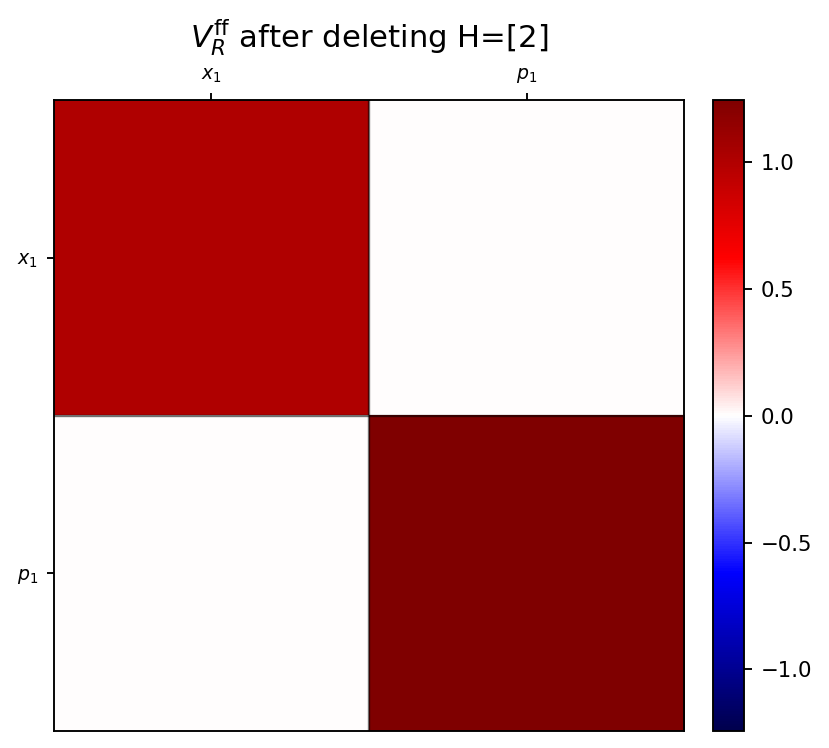

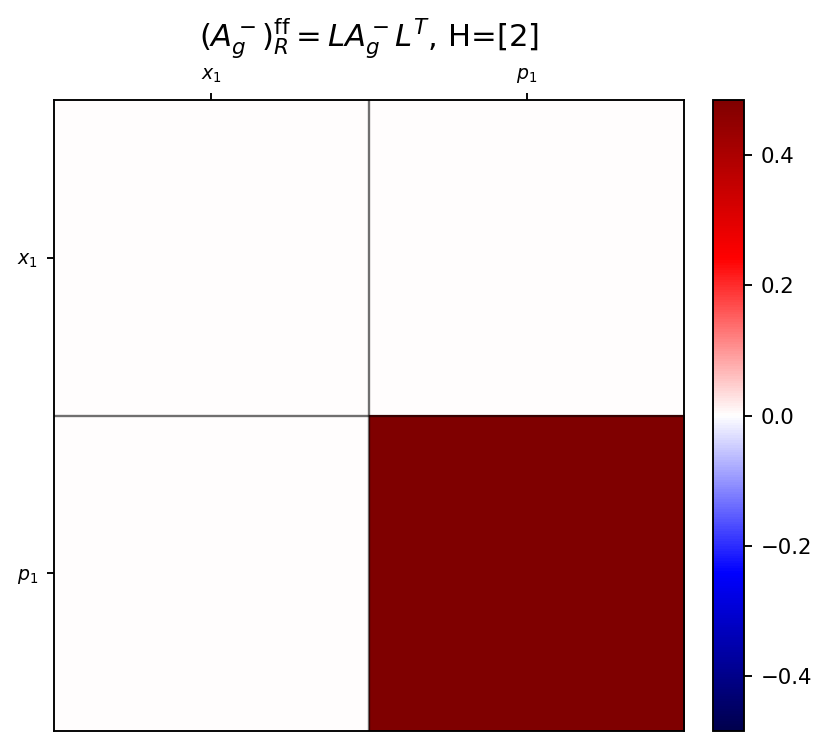

In [81]:
# ============================================================
# 3.1.2 A_R, V_R matrix layer
# Case a: photon subtraction 먼저 한 경우
#
# Inputs from 3.1.1:
#   V_R_ff
#   A_R_ff
#   V_actual_R_ff
#   R0
#   H
#   j
# ============================================================

# -----------------------------
# Basic labels
# -----------------------------
R_labels = list(R0 + 1)  # 1-based node labels for display
r = len(R_labels)

print("Deleted nodes H =", H)
print("Remaining nodes R =", R_labels)
print("photon-subtracted node j =", j)
print("Number of remaining modes =", r)

# -----------------------------
# Matrix sanity checks
# -----------------------------
print("V_R_ff shape =", V_R_ff.shape)
print("A_R_ff shape =", A_R_ff.shape)
print("V_actual_R_ff shape =", V_actual_R_ff.shape)

print("V_R_ff symmetric check:", np.linalg.norm(V_R_ff - V_R_ff.T) < 1e-10)
print("A_R_ff symmetric check:", np.linalg.norm(A_R_ff - A_R_ff.T) < 1e-10)
print("V_actual_R_ff symmetric check:", np.linalg.norm(V_actual_R_ff - V_actual_R_ff.T) < 1e-10)

# -----------------------------
# Optional: print matrices numerically
# -----------------------------
show_mat(V_R_ff, name=r"V_R^{ff} = ")
show_mat(A_R_ff, name=r"(A_g^-)_R^{ff} = ")
show_mat(V_actual_R_ff, name=r"V_actual,R^{ff} = V_R^{ff} + (A_g^-)_R^{ff} = ")

# -----------------------------
# Draw Gaussian envelope covariance
# Mattia-style V matrix
# -----------------------------
# draw_phase_matrix(
#     V_R_ff,
#     title=rf"$V_R^{{\rm ff}}$ after deleting H={H}",
#     positive=False,
#     cmap="seismic",
#     tick_step=1,
#     figsize=(5, 4.5),
#     grid=True
# )

# -----------------------------
# Draw non-Gaussian correction matrix
# A_R_ff = L A_minus L^T
# -----------------------------
# draw_phase_matrix(
#     A_R_ff,
#     title=rf"$(A_g^-)_R^{{\rm ff}} = L A_g^- L^T$, H={H}",
#     positive=False,
#     cmap="seismic",
#     tick_step=1,
#     figsize=(5, 4.5),
#     grid=True
# )

# -----------------------------
# Draw actual covariance
# This is not Mattia's V.
# This is the actual second moment matrix of the non-Gaussian state.
# -----------------------------
# draw_phase_matrix(
#     V_actual_R_ff,
#     title=rf"$V_{{\rm actual,R}}^{{\rm ff}} = V_R^{{\rm ff}} + (A_g^-)_R^{{\rm ff}}$",
#     positive=False,
#     cmap="seismic",
#     tick_step=1,
#     figsize=(5, 4.5),
#     grid=True
# )



# mode_labels로 원래 노드 번호(1-based)를 전달해서 라벨을 x2,x5,x6 / p2,p5,p6로 표시
draw_phase_matrix(
    V_R_ff,
    title=rf"$V_R^{{\rm ff}}$ after deleting H={H}",
    mode_labels=R_labels,
    positive=False,
    cmap="seismic",
    tick_step=1,
    figsize=(5, 4.5),
    grid=True,
)
draw_phase_matrix(
    A_R_ff,
    title=rf"$(A_g^-)_R^{{\rm ff}} = L A_g^- L^T$, H={H}",
    mode_labels=R_labels,
    positive=False,
    cmap="seismic",
    tick_step=1,
    figsize=(5, 4.5),
    grid=True,
)
# draw_phase_matrix(
#     V_actual_R_ff,
#     title=rf"$V_{{\rm actual,R}}^{{\rm ff}} = V_R^{{\rm ff}} + (A_g^-)_R^{{\rm ff}}$",
#     mode_labels=R_labels,
#     positive=False,
#     cmap="seismic",
#     tick_step=1,
#     figsize=(5, 4.5),
#     grid=True,
# )

In [82]:
def estimate_effective_adjacency(V_R_ff, tol=1e-12):
    """
    Input:
        V_R_ff: 2r x 2r matrix in ordering (x_R, p_R)

    Returns:
        Gamma_px: adjacency estimate from nullifier delta = p - Gamma x
        V_delta_px: nullifier covariance for delta = p - Gamma x
        Gamma_xp: optional estimate from delta = x - Gamma p
        V_delta_xp: optional diagnostic
    """
    N = V_R_ff.shape[0]
    assert N % 2 == 0, "V_R_ff must be 2r x 2r"
    r = N // 2

    V_xx = V_R_ff[:r, :r]
    V_xp = V_R_ff[:r, r:]
    V_px = V_R_ff[r:, :r]
    V_pp = V_R_ff[r:, r:]

    pinv_xx = np.linalg.pinv(V_xx, rcond=tol)
    pinv_pp = np.linalg.pinv(V_pp, rcond=tol)

    # Main CV graph convention: delta = p - Gamma x
    Gamma_px = V_px @ pinv_xx

    V_delta_px = (
        V_pp
        - Gamma_px @ V_xp
        - V_px @ Gamma_px.T
        + Gamma_px @ V_xx @ Gamma_px.T
    )
    V_delta_px = 0.5 * (V_delta_px + V_delta_px.T)

    # Optional diagnostic only: delta = x - Gamma p
    Gamma_xp = V_xp @ pinv_pp

    V_delta_xp = (
        V_xx
        - Gamma_xp @ V_px
        - V_xp @ Gamma_xp.T
        + Gamma_xp @ V_pp @ Gamma_xp.T
    )
    V_delta_xp = 0.5 * (V_delta_xp + V_delta_xp.T)

    return Gamma_px, np.diag(V_delta_px), V_delta_px, Gamma_xp, np.diag(V_delta_xp), V_delta_xp

Main nullifier: p - Gamma x
nullifier variances: [1.25]
Diagnostic alternative: x - Gamma p
alternative nullifier variances: [1.]


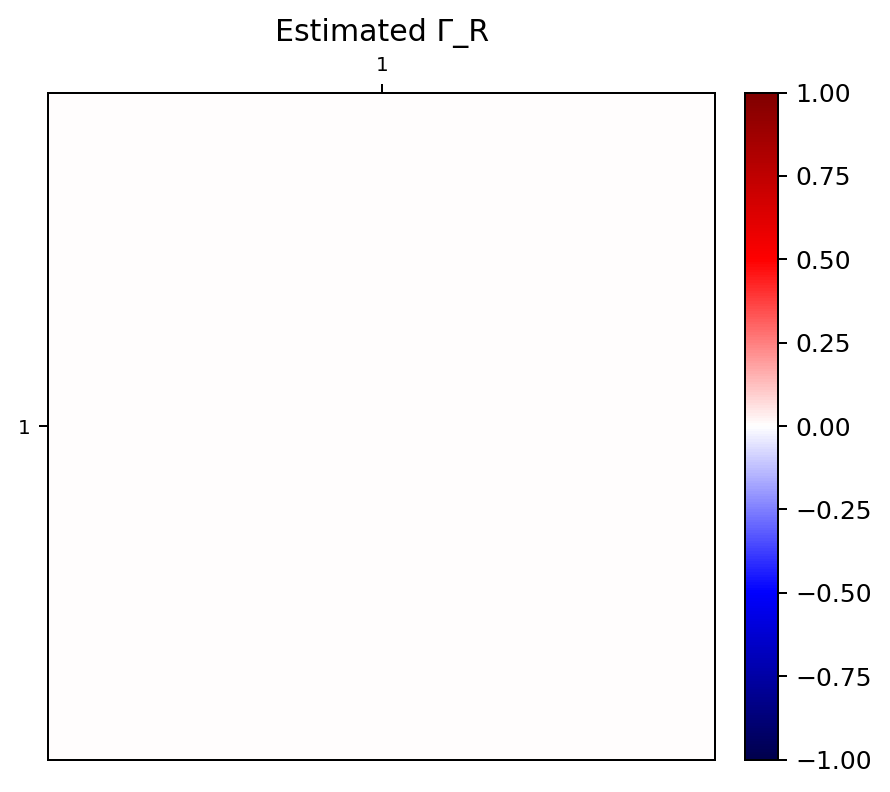

{0: (0.0, 0.0)}
{0: '1'}


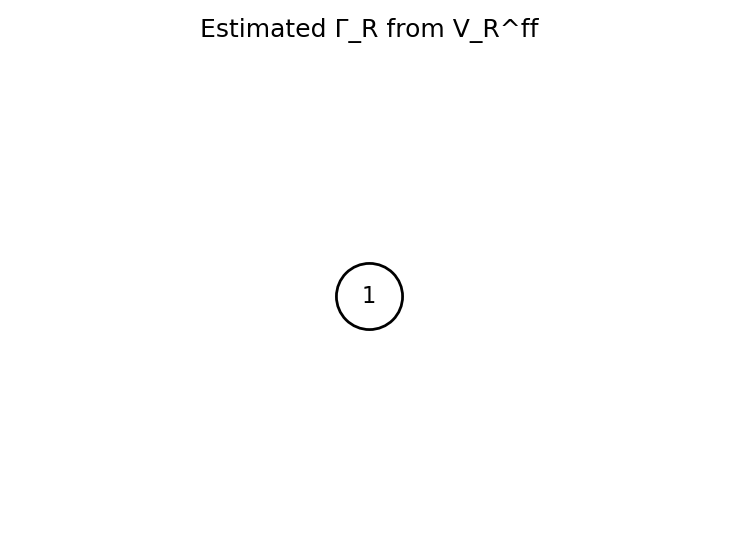

{0: (0.0, 0.0)}

In [83]:
Gamma_R, nullvar_R, Vdelta_R, Gamma_alt, nullvar_alt, Vdelta_alt = estimate_effective_adjacency(V_R_ff)

print("Main nullifier: p - Gamma x")
print("nullifier variances:", nullvar_R)

print("Diagnostic alternative: x - Gamma p")
print("alternative nullifier variances:", nullvar_alt)

draw_mat(Gamma_R, title="Estimated Γ_R", cmap="seismic", label=False, digits=2, grid=True)
# node 색상에 nullifier variance 표시, 라벨=2,5,6
pos_R, labels_R = make_reduced_pos_and_labels(pos, R0)

print(pos_R)
print(labels_R)
plot_graph_from_matrix(
    Gamma_R,
    #node_values=nullvar_R,
    title="Estimated Γ_R from V_R^ff",
    pos=pos_R,
    draw_labels=True,
    labels=labels_R
)

##### graph layer

R original labels = [1]
Kex_x = [-0.]
Kex_p = [-0.24489796]


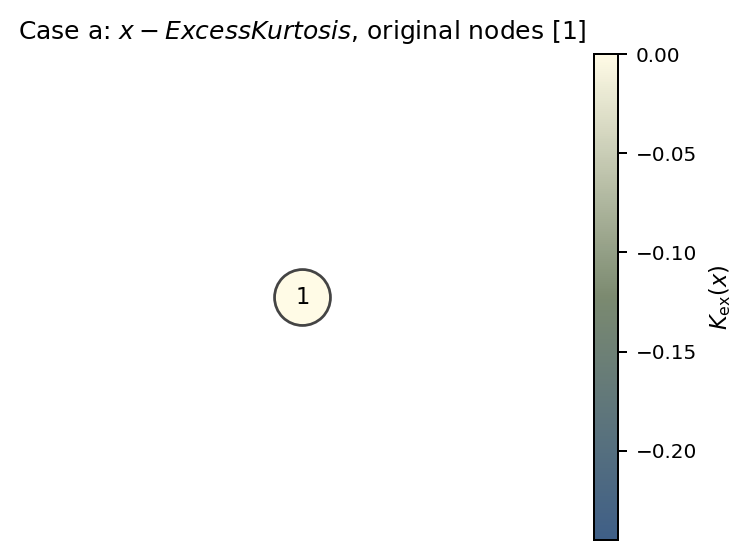

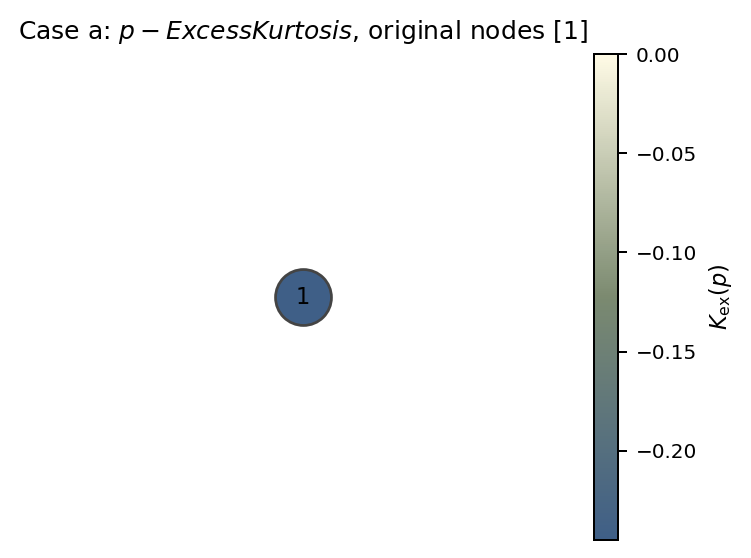

In [84]:
# ============================================================
# 3.1.3 Graph layer - kurtosis reflected graph
# Case a: photon subtraction 먼저 한 경우
#
# Required variables:
#   V_R_ff, A_R_ff, R0, Gamma_R, pos
#   plot_graph_from_matrix(..., labels=labels_R) 로 수정되어 있어야 함
# ============================================================

r = len(R0)

# ------------------------------------------------------------
# 1. Node-wise excess kurtosis
# ------------------------------------------------------------
Kex_x = np.zeros(r)
Kex_p = np.zeros(r)

for k in range(r):
    x_idx = k
    p_idx = k + r

    # x quadrature
    v_x = V_R_ff[x_idx, x_idx]
    a_x = A_R_ff[x_idx, x_idx]
    Kex_x[k] = -3 * a_x**2 / (v_x + a_x)**2

    # p quadrature
    v_p = V_R_ff[p_idx, p_idx]
    a_p = A_R_ff[p_idx, p_idx]
    Kex_p[k] = -3 * a_p**2 / (v_p + a_p)**2

print("R original labels =", list(R0 + 1))
print("Kex_x =", Kex_x)
print("Kex_p =", Kex_p)

# ------------------------------------------------------------
# 2. Reduced graph position and labels
#    Gamma_R node index: 0,1,2,...
#    display label: original node number, e.g. 2,5,6
# ------------------------------------------------------------
pos_R = {
    local_idx: pos[int(original_idx)]
    for local_idx, original_idx in enumerate(R0)
}

labels_R = {
    local_idx: int(original_idx) + 1
    for local_idx, original_idx in enumerate(R0)
}

# common color scale for x and p kurtosis
vmin_K = min(np.nanmin(Kex_x), np.nanmin(Kex_p))
vmax_K = max(np.nanmax(Kex_x), np.nanmax(Kex_p))

# ------------------------------------------------------------
# 3. Draw graph colored by x-quadrature excess kurtosis
# ------------------------------------------------------------
pos_R = plot_graph_from_matrix(
    Gamma_R,
    node_values=Kex_x,
    title=rf"Case a: $x-Excess Kurtosis$, original nodes {list(R0 + 1)}",
    pos=pos_R,
    labels=labels_R,
    draw_labels=True,
    cmap=blue,
    vmin=vmin_K,
    vmax=vmax_K,
    colorbar_label=r"$K_{\rm ex}(x)$"
)

# ------------------------------------------------------------
# 4. Draw graph colored by p-quadrature excess kurtosis
# ------------------------------------------------------------
pos_R = plot_graph_from_matrix(
    Gamma_R,
    node_values=Kex_p,
    title=rf"Case a: $p-Excess Kurtosis$, original nodes {list(R0 + 1)}",
    pos=pos_R,
    labels=labels_R,
    draw_labels=True,
    cmap=blue,
    vmin=vmin_K,
    vmax=vmax_K,
    colorbar_label=r"$K_{\rm ex}(p)$"
)

node local 1, original 1
V1 =
[[1.   0.  ]
 [0.   1.25]]
A1 =
[[0.  0. ]
 [0.  0.5]]
Tr(V^-1 A) = 0.4
W(0) condition Tr>2 ? False
min W = 1.440233984291176e-22
max W = 0.11383185988725122
has negativity? False


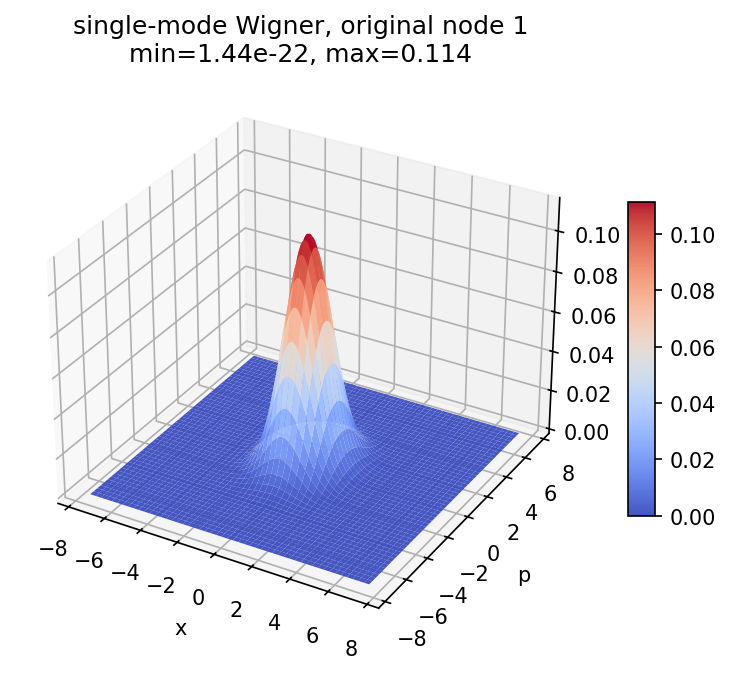

In [85]:
# ============================================================
# 3.1.3 Graph layer - single-mode Wigner function
# Case a: photon subtraction 먼저 한 경우
#
# Inputs:
#   V_R_ff, A_R_ff, R0
#
# ordering in reduced R-space:
#   q_R = (x_R, p_R)
# ============================================================

from mpl_toolkits.mplot3d import Axes3D

def single_mode_wigner_from_VA(V_eff, A_eff, node, m_eff, xlim=10, n=150):
    """
    node  : local node label, 1-based in reduced R-space
    m_eff : number of remaining modes
    V_eff : Gaussian envelope covariance
    A_eff : non-Gaussian correction matrix

    ordering = (x1,...,xm,p1,...,pm)
    """

    k = node - 1
    idx = [k, k + m_eff]

    V1 = V_eff[np.ix_(idx, idx)]
    A1 = A_eff[np.ix_(idx, idx)]

    Vinv = np.linalg.inv(V1)
    detV = np.linalg.det(V1)

    xs = np.linspace(-xlim, xlim, n)
    ps = np.linspace(-xlim, xlim, n)
    X, P = np.meshgrid(xs, ps)

    Z = np.stack([X, P], axis=-1)

    quad = np.einsum("...i,ij,...j->...", Z, Vinv, Z)

    tr_term = np.trace(Vinv @ A1)

    poly_quad = np.einsum(
        "...i,ij,...j->...",
        Z,
        Vinv @ A1 @ Vinv,
        Z
    )

    pref = 1 / (2 * np.pi * np.sqrt(detV))

    W = pref * np.exp(-0.5 * quad) * (
        1 - 0.5 * tr_term + 0.5 * poly_quad
    )

    return X, P, W, V1, A1


def plot_single_mode_wigner_static(V_eff, A_eff, node, m_eff, original_label=None, xlim=10, n=150):
    X, P, W, V1, A1 = single_mode_wigner_from_VA(
        V_eff, A_eff, node=node, m_eff=m_eff, xlim=xlim, n=n
    )

    label = node if original_label is None else original_label

    print(f"node local {node}, original {label}")
    print("V1 =")
    print(V1)
    print("A1 =")
    print(A1)
    print("Tr(V^-1 A) =", np.trace(np.linalg.inv(V1) @ A1))
    print("W(0) condition Tr>2 ?", np.trace(np.linalg.inv(V1) @ A1) > 2)
    print("min W =", np.min(W))
    print("max W =", np.max(W))
    print("has negativity?", np.min(W) < 0)

    fig = plt.figure(figsize=(6, 4.5), dpi=150)
    ax = fig.add_subplot(111, projection="3d")

    surf = ax.plot_surface(
        X, P, W,
        cmap="coolwarm",
        linewidth=0,
        antialiased=True,
        alpha=0.95
    )

    ax.set_title(
        rf"single-mode Wigner, original node {label}" + "\n"
        + rf"min={np.min(W):.3g}, max={np.max(W):.3g}"
    )
    ax.set_xlabel("x")
    ax.set_ylabel("p")
    ax.set_zlabel("W")

    fig.colorbar(surf, shrink=0.55, aspect=12)
    plt.tight_layout()
    plt.show()

    return X, P, W, V1, A1
R_labels = list(R0 + 1)
r = len(R_labels)

for local_node in range(1, r + 1):
    original_node = R_labels[local_node - 1]

    X, P, W, V1, A1 = plot_single_mode_wigner_static(
        V_R_ff,
        A_R_ff,
        node=local_node,
        m_eff=r,
        original_label=original_node,
        xlim=7.5,
        n=300
    )

In [86]:
# ============================================================
# Interactive single-mode Wigner plot
# Case a: photon subtraction 먼저 한 경우
#
# Inputs:
#   V_R_ff, A_R_ff, R0
#
# ordering:
#   q_R = (x_R, p_R)
# ============================================================

import plotly.graph_objects as go
import numpy as np

def single_mode_wigner_grid_from_VA(V_eff, A_eff, node, m_eff, xlim=10, n=150):
    """
    node  : local node label, 1-based in reduced R-space
    m_eff : number of remaining modes
    V_eff : Gaussian envelope matrix
    A_eff : non-Gaussian correction matrix

    ordering = (x1,...,xm,p1,...,pm)
    """

    k = node - 1
    idx = [k, k + m_eff]  # [x_k, p_k]

    V1 = V_eff[np.ix_(idx, idx)]
    A1 = A_eff[np.ix_(idx, idx)]

    Vinv = np.linalg.inv(V1)
    detV = np.linalg.det(V1)

    xs = np.linspace(-xlim, xlim, n)
    ps = np.linspace(-xlim, xlim, n)
    X, P = np.meshgrid(xs, ps)

    Z = np.stack([X, P], axis=-1)

    quad = np.einsum("...i,ij,...j->...", Z, Vinv, Z)

    tr_term = np.trace(Vinv @ A1)

    poly_quad = np.einsum(
        "...i,ij,...j->...",
        Z,
        Vinv @ A1 @ Vinv,
        Z
    )

    pref = 1 / (2 * np.pi * np.sqrt(detV))

    W = pref * np.exp(-0.5 * quad) * (
        1 - 0.5 * tr_term + 0.5 * poly_quad
    )

    return X, P, W, V1, A1


def plot_single_mode_wigner_interactive(
    V_eff,
    A_eff,
    node,
    m_eff,
    original_label=None,
    xlim=10,
    n=160,
):
    """
    Interactive 3D Wigner plot using Plotly.
    """

    X, P, W, V1, A1 = single_mode_wigner_grid_from_VA(
        V_eff,
        A_eff,
        node=node,
        m_eff=m_eff,
        xlim=xlim,
        n=n
    )

    label = node if original_label is None else original_label

    W_min = np.nanmin(W)
    W_max = np.nanmax(W)

    print(f"local node {node} -> original node {label}")
    print("V1 =")
    print(V1)
    print("A1 =")
    print(A1)
    print("Tr(V1^{-1} A1) =", np.trace(np.linalg.inv(V1) @ A1))
    print("W(0) negativity condition Tr > 2 ?",
          np.trace(np.linalg.inv(V1) @ A1) > 2)
    print("min W =", W_min)
    print("max W =", W_max)
    print("has negativity?", W_min < 0)

    fig = go.Figure(
        data=[
            go.Surface(
                x=X,
                y=P,
                z=W,
                colorscale="RdBu",
                reversescale=True,
                colorbar=dict(title="W"),
            )
        ]
    )

    fig.update_layout(
        title=(
            f"Single-mode Wigner, original node {label}<br>"
            f"min={W_min:.3g}, max={W_max:.3g}"
        ),
        scene=dict(
            xaxis_title="x",
            yaxis_title="p",
            zaxis_title="W",
            camera=dict(
                eye=dict(x=1.6, y=-1.8, z=1.2)
            ),
        ),
        width=750,
        height=600,
    )

    fig.show()

    return X, P, W, V1, A1

R_labels = list(R0 + 1)
r = len(R_labels)

for local_node in range(1, r + 1):
    original_node = R_labels[local_node - 1]

    X, P, W, V1, A1 = plot_single_mode_wigner_interactive(
        V_R_ff,
        A_R_ff,
        node=local_node,
        m_eff=r,
        original_label=original_node,
        xlim=10,
        n=160
    )

local node 1 -> original node 1
V1 =
[[1.   0.  ]
 [0.   1.25]]
A1 =
[[0.  0. ]
 [0.  0.5]]
Tr(V1^{-1} A1) = 0.4
W(0) negativity condition Tr > 2 ? False
min W = 1.9596162653907662e-39
max W = 0.11356708221107843
has negativity? False


####  3.2 Neighborhood Deletion FeedFoward w/ x measurement(by HOMODYNE), and afterward, Photon subtraction 

#### Initial variable

In [87]:
# ============================================================
# 3.2.1 Initial variable layer
# Case b: HD+FF deletion 먼저, photon subtraction 나중
#
# Inputs from previous cells:
#   V_R_ff : Gaussian envelope after deletion
#   R0     : remaining original nodes, 0-based
#   sub_node or j : photon-subtracted original node label, 1-based
#
# ordering in reduced R-space:
#   q_R = (x1,...,xr,p1,...,pr)
# ============================================================

r = len(R0)
R_labels = list(R0 + 1)

# photon subtraction target
j = sub_node          # original node label, 1-based
j0 = j - 1            # 0-based original node index

if j0 not in R0:
    raise ValueError(f"subtraction node {j} is deleted. Remaining nodes are {R_labels}")

# reduced local index
j_local0 = np.where(R0 == j0)[0][0]     # 0-based local index
j_local = j_local0 + 1                  # 1-based local label

print("Case b: deletion -> photon subtraction")
print("Remaining original nodes R =", R_labels)
print("photon subtraction original node =", j)
print("reduced local node =", j_local)

# ------------------------------------------------------------
# Build reduced projector Pi_g_R
# node-local photon subtraction on reduced node j_local
# ------------------------------------------------------------
g_R = np.zeros(r)
g_R[j_local0] = 1.0

Pi_x_R = np.outer(g_R, g_R)

Pi_g_R = np.block([
    [Pi_x_R,              np.zeros((r, r))],
    [np.zeros((r, r)),    Pi_x_R]
])

print("Pi_g_R projector check:",
      bool(np.linalg.norm(Pi_g_R @ Pi_g_R - Pi_g_R) < 1e-10))

# ------------------------------------------------------------
# A_minus after deletion
# A_minus_post = 2 (V_R_ff - I) Pi_g_R (V_R_ff - I)
#                / Tr[(V_R_ff - I) Pi_g_R]
# ------------------------------------------------------------
I_2r = np.eye(2 * r)

denom_post = np.trace((V_R_ff - I_2r) @ Pi_g_R)

print("denom_post =", denom_post)

if np.isclose(denom_post, 0):
    raise ValueError("denom_post is close to zero: subtraction mode may be vacuum-like after deletion.")

A_minus_post = (
    2 * (V_R_ff - I_2r) @ Pi_g_R @ (V_R_ff - I_2r)
    / denom_post
)

A_minus_post = 0.5 * (A_minus_post + A_minus_post.T)

print("A_minus_post symmetric check:",
      bool(np.linalg.norm(A_minus_post - A_minus_post.T) < 1e-10))

# ------------------------------------------------------------
# Case b final matrices
# ------------------------------------------------------------
V_R_post = V_R_ff
A_R_post = A_minus_post
V_actual_R_post = V_R_post + A_R_post

show_mat(A_R_post, name=r"A_minus_post = ")
show_mat(V_R_post, name=r"V_R_post = ")
show_mat(V_actual_R_post, name=r"V_actual_R_post = ")

Case b: deletion -> photon subtraction
Remaining original nodes R = [1]
photon subtraction original node = 1
reduced local node = 1
Pi_g_R projector check: True
denom_post = 0.25
A_minus_post symmetric check: True
A_minus_post = 


,1,2
1,0.000,0.000
2,0.000,0.500


V_R_post = 


,1,2
1,1.000,0.000
2,0.000,1.250


V_actual_R_post = 


,1,2
1,1.000,0.000
2,0.000,1.750


#### matrix layer

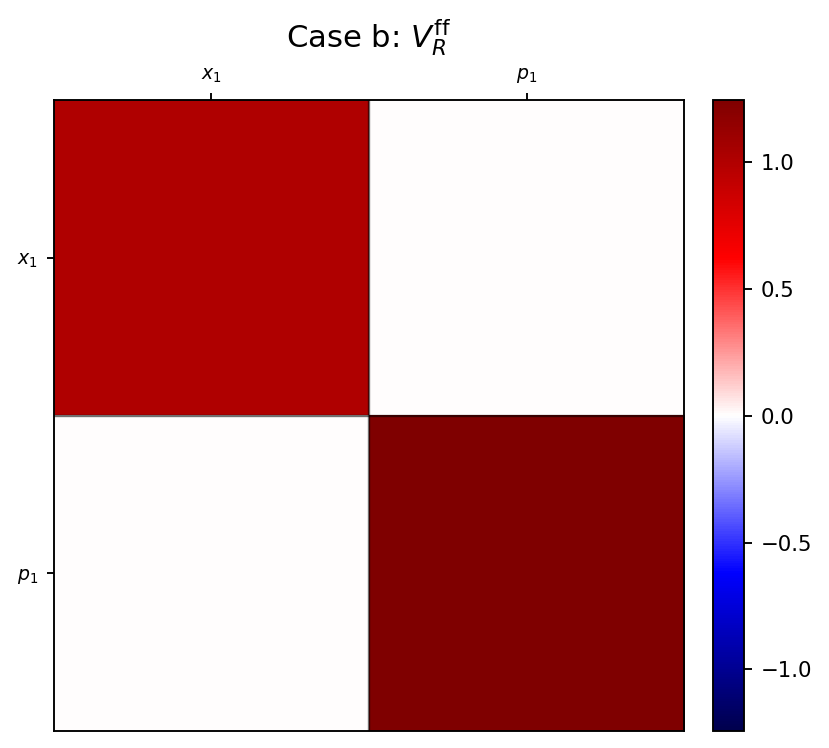

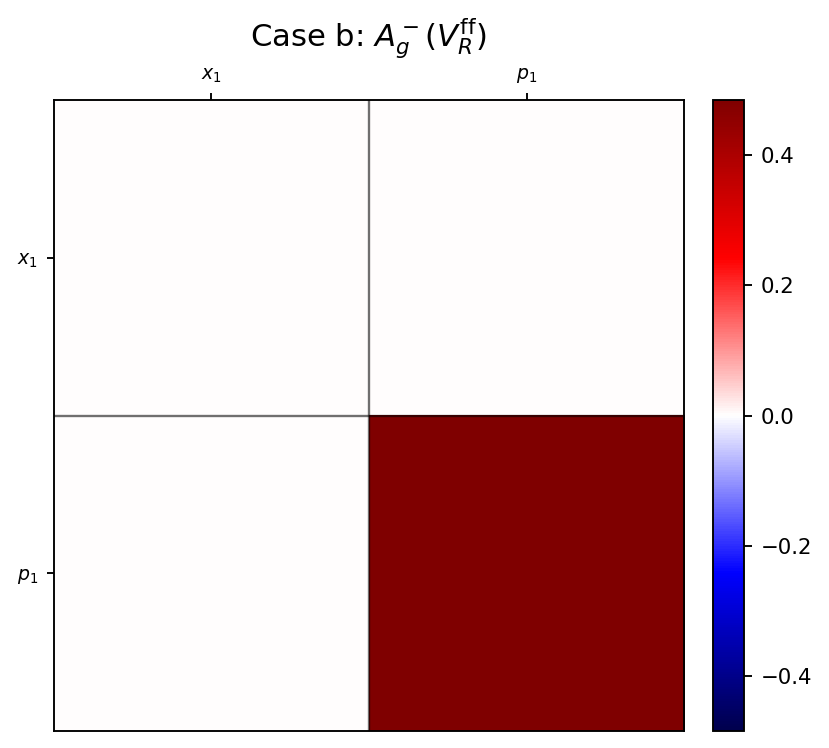

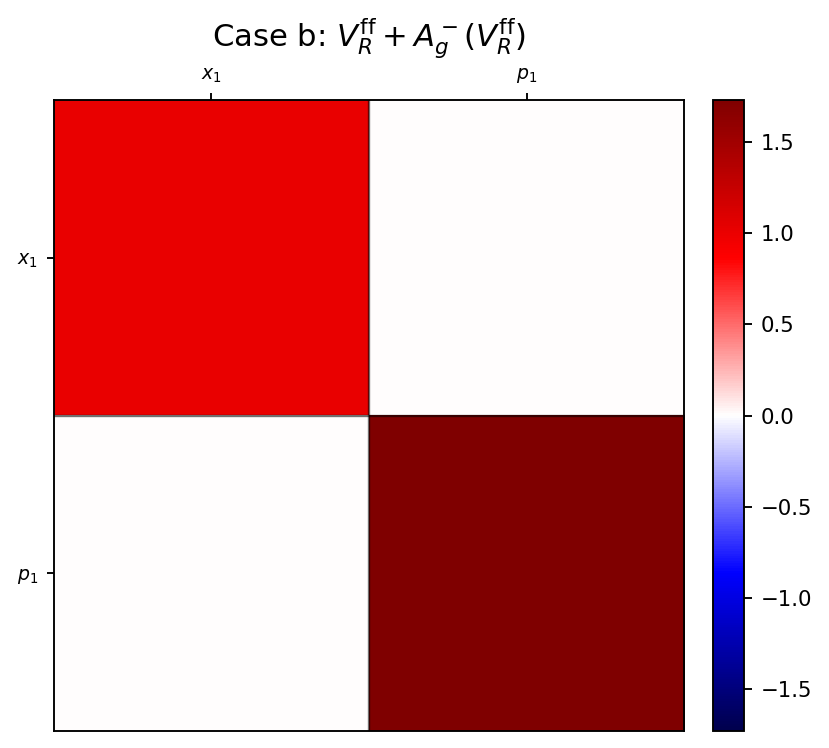

In [88]:
# ============================================================
# 3.2.2 A_R, V_R matrix layer
# Case b: deletion 먼저, photon subtraction 나중
# ============================================================

draw_phase_matrix(
    V_R_post,
    title=rf"Case b: $V_R^{{\rm ff}}$",
    positive=False,
    cmap="seismic",
    tick_step=1,
    figsize=(5, 4.5),
    grid=True
)

draw_phase_matrix(
    A_R_post,
    title=rf"Case b: $A^-_g(V_R^{{\rm ff}})$",
    positive=False,
    cmap="seismic",
    tick_step=1,
    figsize=(5, 4.5),
    grid=True
)

draw_phase_matrix(
    V_actual_R_post,
    title=rf"Case b: $V_R^{{\rm ff}} + A^-_g(V_R^{{\rm ff}})$",
    positive=False,
    cmap="seismic",
    tick_step=1,
    figsize=(5, 4.5),
    grid=True
)

In [89]:
# ============================================================
# 3.2.3 Graph layer - kurtosis only
# Case b: deletion 먼저, photon subtraction 나중
#
# Inputs:
#   V_R_post : Gaussian envelope after deletion
#   A_R_post : non-Gaussian correction after photon subtraction on deleted graph
#   R0       : remaining nodes, 0-based original labels
#   j_local0 : target node local index in R-space, 0-based
#
# ordering in reduced R-space:
#   q_R = (x_R, p_R)
# ============================================================

V_eff = V_R_post
A_eff = A_R_post

r = len(R0)
R_labels = list(R0 + 1)   # original node labels, 1-based

def excess_kurtosis_1d(v, a):
    """
    chi(lambda) = exp[-v lambda^2 / 2] * (1 - a lambda^2 / 2)

    actual variance = v + a
    excess kurtosis = -3 a^2 / (v+a)^2
    """
    var = v + a
    if np.isclose(var, 0):
        return np.nan
    return -3 * a**2 / var**2


# node별 x, p kurtosis 계산
Kex_x_post = np.zeros(r)
Kex_p_post = np.zeros(r)

var_x_actual_post = np.zeros(r)
var_p_actual_post = np.zeros(r)

v_x_env_post = np.zeros(r)
v_p_env_post = np.zeros(r)

a_x_post = np.zeros(r)
a_p_post = np.zeros(r)

for k in range(r):
    x_idx = k
    p_idx = k + r

    # x quadrature
    v_x_env_post[k] = V_eff[x_idx, x_idx]
    a_x_post[k] = A_eff[x_idx, x_idx]
    var_x_actual_post[k] = v_x_env_post[k] + a_x_post[k]
    Kex_x_post[k] = excess_kurtosis_1d(v_x_env_post[k], a_x_post[k])

    # p quadrature
    v_p_env_post[k] = V_eff[p_idx, p_idx]
    a_p_post[k] = A_eff[p_idx, p_idx]
    var_p_actual_post[k] = v_p_env_post[k] + a_p_post[k]
    Kex_p_post[k] = excess_kurtosis_1d(v_p_env_post[k], a_p_post[k])


# table
kurtosis_post_df = pd.DataFrame({
    "node": R_labels,
    "v_x_env": v_x_env_post,
    "a_x": a_x_post,
    "var_x_actual": var_x_actual_post,
    "Kex_x": Kex_x_post,
    "v_p_env": v_p_env_post,
    "a_p": a_p_post,
    "var_p_actual": var_p_actual_post,
    "Kex_p": Kex_p_post,
})

display(kurtosis_post_df.style.format("{:.4f}", subset=kurtosis_post_df.columns[1:]))

print("target original node =", j)
print("target local index =", j_local)
print("target Kex_x =", Kex_x_post[j_local0])
print("target Kex_p =", Kex_p_post[j_local0])

,node,v_x_env,a_x,var_x_actual,Kex_x,v_p_env,a_p,var_p_actual,Kex_p
0,1,1.0000,0.0000,1.0000,-0.0000,1.2500,0.5000,1.7500,-0.2449


target original node = 1
target local index = 1
target Kex_x = -0.0
target Kex_p = -0.24489795918367346


vmin_K_post = -0.24489795918367346
vmax_K_post = -0.0


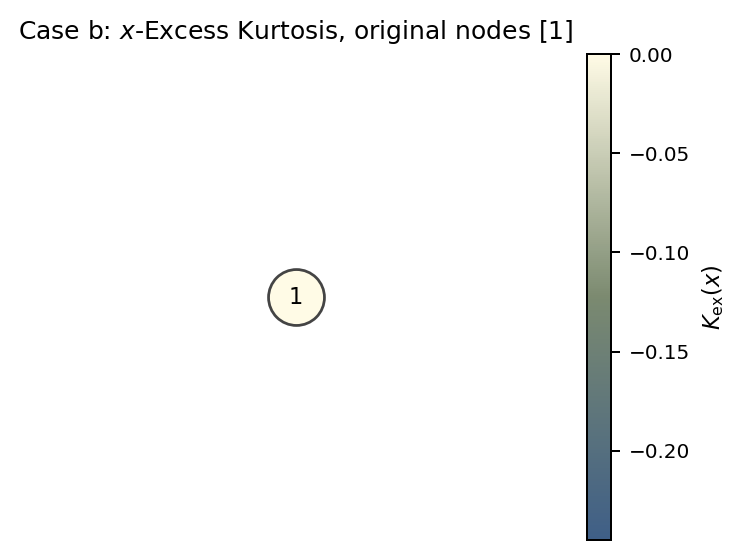

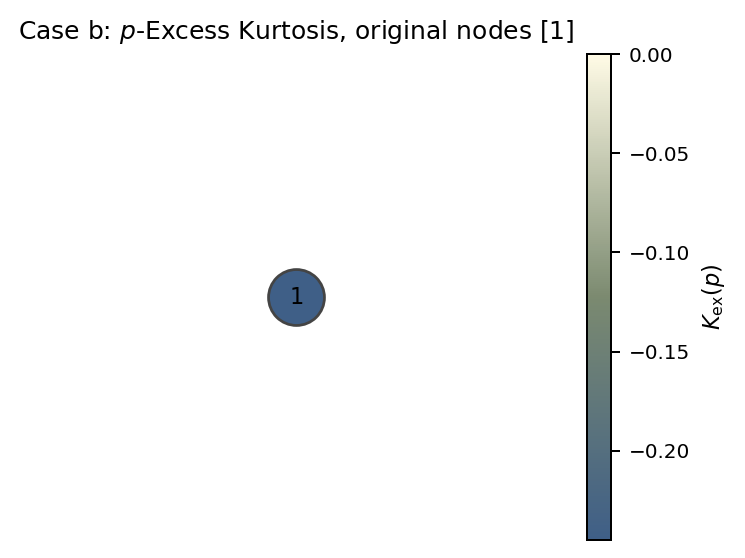

In [90]:
# ============================================================
# 3.2.3 Graph layer - kurtosis reflected graph
# Case b: deletion 먼저, photon subtraction 나중
# ============================================================

# Reduced graph position and labels
pos_R = {
    local_idx: pos[int(original_idx)]
    for local_idx, original_idx in enumerate(R0)
}

labels_R = {
    local_idx: int(original_idx) + 1
    for local_idx, original_idx in enumerate(R0)
}

# common color scale for x and p kurtosis
vmin_K_post = min(np.nanmin(Kex_x_post), np.nanmin(Kex_p_post))
vmax_K_post = max(np.nanmax(Kex_x_post), np.nanmax(Kex_p_post))
print("vmin_K_post =", vmin_K_post)
print("vmax_K_post =", vmax_K_post)
# x-quadrature excess kurtosis graph
pos_R = plot_graph_from_matrix(
    Gamma_R,
    node_values=Kex_x_post,
    title=rf"Case b: $x$-Excess Kurtosis, original nodes {list(R0 + 1)}",
    pos=pos_R,
    labels=labels_R,
    draw_labels=True,
    cmap=blue,
    vmin=vmin_K_post,
    vmax=vmax_K_post,
    colorbar_label=r"$K_{\rm ex}(x)$"
)

# p-quadrature excess kurtosis graph
pos_R = plot_graph_from_matrix(
    Gamma_R,
    node_values=Kex_p_post,
    title=rf"Case b: $p$-Excess Kurtosis, original nodes {list(R0 + 1)}",
    pos=pos_R,
    labels=labels_R,
    draw_labels=True,
    cmap=blue,
    vmin=vmin_K_post,
    vmax=vmax_K_post,
    colorbar_label=r"$K_{\rm ex}(p)$"
)

reduced node 1  <->  original node 1


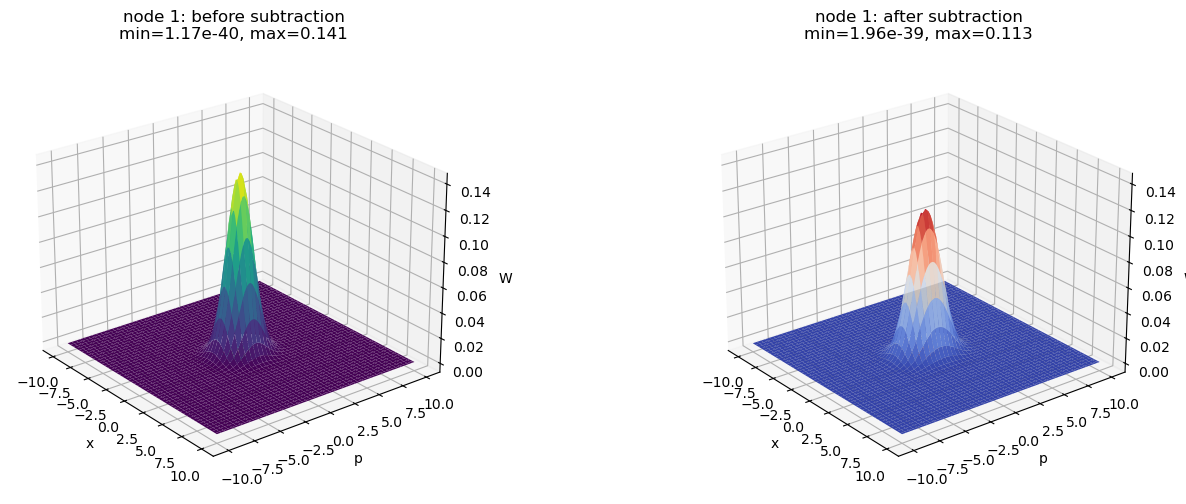

In [91]:
# ============================================================
# 3.2.3 Graph layer - single-mode Wigner function
# Case b: deletion 먼저, photon subtraction 나중
#
# V_eff = V_R_post
# A_eff = A_R_post
# node index는 reduced-space 기준: 1,2,...,r
# ============================================================

V_eff = V_R_post
A_eff = A_R_post

r = len(R0)
R_labels = list(R0 + 1)

nodes_to_plot = range(1, r + 1)

plot_static = True
plot_interactive = False

for node in nodes_to_plot:
    original_node = R_labels[node - 1]

    print("=" * 60)
    print(f"reduced node {node}  <->  original node {original_node}")

    if plot_static:
        plot_node_wigner_3d_static(
            V_eff,
            A_eff,
            node=node,
            m=r,
            xlim=10,
            n=100
        )

    if plot_interactive:
        plot_node_wigner_3d_interactive(
            V_eff,
            A_eff,
            node=node,
            m=r,
            xlim=10,
            n=100
        )

In [92]:
# ============================================================
# Interactive single-mode Wigner plot
# Case b: deletion 먼저, photon subtraction 나중
#
# Inputs:
#   V_R_post, A_R_post, R0
#
# ordering:
#   q_R = (x_R, p_R)
# ============================================================

R_labels = list(R0 + 1)
r = len(R_labels)

for local_node in range(1, r + 1):
    original_node = R_labels[local_node - 1]

    X, P, W, V1, A1 = plot_single_mode_wigner_interactive(
        V_R_post,
        A_R_post,
        node=local_node,
        m_eff=r,
        original_label=original_node,
        xlim=10,
        n=160
    )

local node 1 -> original node 1
V1 =
[[1.   0.  ]
 [0.   1.25]]
A1 =
[[0.  0. ]
 [0.  0.5]]
Tr(V1^{-1} A1) = 0.4
W(0) negativity condition Tr > 2 ? False
min W = 1.9596162653907662e-39
max W = 0.11356708221107843
has negativity? False


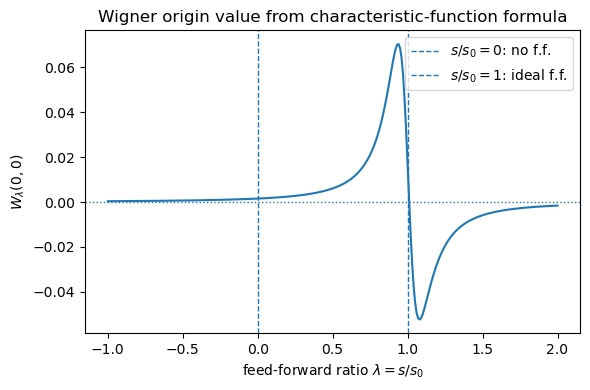

lambda =  0.000, W(0,0) =  0.00157577
lambda =  0.500, W(0,0) =  0.00609533
lambda =  1.000, W(0,0) =  0.01670687

Most negative point in scan:
lambda =  1.08000
W(0,0) = -0.05233423


In [93]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Convention
# ============================================================
# r = (x1, x2, p1, p2)^T
# vacuum covariance = I
# hbar = 2 convention
#
# Gaussian Wigner:
# W_G(r) = exp[-1/2 r^T V^{-1} r] / ((2pi)^m sqrt(det V))
#
# For one remaining mode:
# W_G(0) = 1 / (2pi sqrt(det V))
# ============================================================


# ============================================================
# Parameters
# ============================================================
s = 10.0       # finite squeezing parameter. V0 = diag(s I, s^{-1} I)
g = 1        # graph edge gain Gamma_12

lambda_min = -1.0
lambda_max = 2.0
n_lambda = 301


# ============================================================
# 1. Build 2-node graph-state covariance matrix
# ============================================================
m = 2
I2 = np.eye(2)
Z2 = np.zeros((2, 2))

Gamma = np.array([
    [0.0, g],
    [g, 0.0]
])

# V0 = diag(s I_x, s^{-1} I_p)
V0 = np.block([
    [s * I2,        Z2],
    [Z2,     (1/s) * I2]
])

# CZ graph symplectic matrix
# (x, p) -> (x, p + Gamma x)
Gsymp = np.block([
    [I2,    Z2],
    [Gamma, I2]
])

V = Gsymp @ V0 @ Gsymp.T


# ============================================================
# 2. Photon subtraction induced matrix A_g^-
#
# Subtraction on mode 1.
# In ordering (x1,x2,p1,p2), mode 1 projector is diag(1,0,1,0).
# ============================================================
I4 = np.eye(4)

P1 = np.diag([1.0, 0.0, 1.0, 0.0])

denom = np.trace((V - I4) @ P1)

if abs(denom) < 1e-12:
    raise ValueError("Photon subtraction denominator is too small. Try different s or g.")

A_minus = 2.0 * (V - I4) @ P1 @ (V - I4) / denom


# ============================================================
# 3. Wigner origin value after partial feed-forward
#
# lambda = s_feedforward / s_measured
#
# lambda = 0 : no feed-forward
# lambda = 1 : ideal feed-forward
#
# x1_out = x1
# p1_out = p1 - lambda * g * x2
#
# r_out = L_lambda r
# ============================================================
def L_matrix(lam, g):
    return np.array([
        [1.0, 0.0,       0.0, 0.0],
        [0.0, -lam * g,  1.0, 0.0]
    ])


def wigner_origin_from_V_A(V_eff, A_eff):
    """
    Photon-subtracted Wigner origin value.

    W(0) = 1/2 [2 - Tr(V^{-1} A)] W_G(0)

    One-mode Gaussian origin:
    W_G(0) = 1 / (2 pi sqrt(det V))
    """
    Vinv = np.linalg.inv(V_eff)
    detV = np.linalg.det(V_eff)

    if detV <= 0:
        return np.nan

    W_G_0 = 1.0 / (2.0 * np.pi * np.sqrt(detV))
    prefactor = 0.5 * (2.0 - np.trace(Vinv @ A_eff))

    return np.real(prefactor * W_G_0)


lambdas = np.linspace(lambda_min, lambda_max, n_lambda)
W0_values = []

for lam in lambdas:
    L = L_matrix(lam, g)

    V_lam = L @ V @ L.T
    A_lam = L @ A_minus @ L.T

    W0 = wigner_origin_from_V_A(V_lam, A_lam)
    W0_values.append(W0)

W0_values = np.array(W0_values)


# ============================================================
# 4. Plot Wigner origin value vs feed-forward ratio
# ============================================================
plt.figure(figsize=(6, 4))
plt.plot(lambdas, W0_values)

plt.axvline(0.0, linestyle="--", linewidth=1, label=r"$s/s_0=0$: no f.f.")
plt.axvline(1.0, linestyle="--", linewidth=1, label=r"$s/s_0=1$: ideal f.f.")
plt.axhline(0.0, linestyle=":", linewidth=1)

plt.xlabel(r"feed-forward ratio $\lambda=s/s_0$")
plt.ylabel(r"$W_\lambda(0,0)$")
plt.title("Wigner origin value from characteristic-function formula")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 5. Print specific values
# ============================================================
for target in [0.0, 0.5, 1.0]:
    idx = np.argmin(np.abs(lambdas - target))
    print(f"lambda = {lambdas[idx]: .3f}, W(0,0) = {W0_values[idx]: .8f}")

idx_min = np.argmin(W0_values)
print()
print(f"Most negative point in scan:")
print(f"lambda = {lambdas[idx_min]: .5f}")
print(f"W(0,0) = {W0_values[idx_min]: .8f}")

Gamma =
[[0.  0.1 0.1 ... 0.1 0.1 0.1]
 [0.1 0.  0.  ... 0.  0.  0. ]
 [0.1 0.  0.  ... 0.  0.  0. ]
 ...
 [0.1 0.  0.  ... 0.  0.  0. ]
 [0.1 0.  0.  ... 0.  0.  0. ]
 [0.1 0.  0.  ... 0.  0.  0. ]]
K = sum_j g_j^2 = 9.990000000000006

Analytic stationary lambdas:
1.0826334517285956
0.9939431248479809

Numerical minimum:
lambda_min = 1.085
W(0,0)    = -0.0038188212739590265

Analytic minimum candidate:
lambda_min = 1.0826334517285956


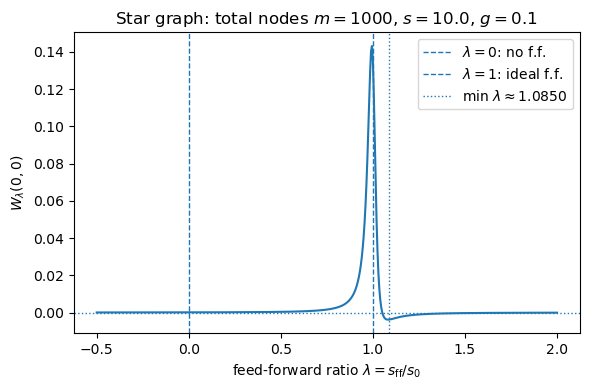

lambda =  0.00000, W(0,0) =  0.0000880761
lambda =  0.50000, W(0,0) =  0.0003677603
lambda =  1.00000, W(0,0) =  0.1352817016
lambda =  1.08500, W(0,0) = -0.0038188213


In [94]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Star graph:
# node 1 connected to nodes 2,...,m
#
# Convention:
# r = (x1, x2, ..., xm, p1, p2, ..., pm)^T
# vacuum covariance = I
# V0 = diag(s I_m, s^{-1} I_m)
# ============================================================


# ============================================================
# Parameters
# ============================================================
m = 1000          # total number of nodes: 1,2,...,10
s = 10.0        # squeezing parameter
g = 0.1         # all edge gains g_j = 1

lambda_min = -0.5
lambda_max = 2.0
n_lambda = 501


# ============================================================
# 1. Build star-graph adjacency matrix Gamma
# ============================================================
Gamma = np.zeros((m, m))

for j in range(1, m):   # Python index 1 means physical node 2
    Gamma[0, j] = g
    Gamma[j, 0] = g

print("Gamma =")
print(Gamma)

K = np.sum(Gamma[0, 1:] ** 2)
print("K = sum_j g_j^2 =", K)


# ============================================================
# 2. Build graph-state covariance matrix
#
# V0 = diag(s I_x, s^{-1} I_p)
# Gsymp = [[I, 0],
#          [Gamma, I]]
# V = Gsymp V0 Gsymp^T
# ============================================================
I_m = np.eye(m)
Z_m = np.zeros((m, m))

V0 = np.block([
    [s * I_m,        Z_m],
    [Z_m,     (1/s) * I_m]
])

Gsymp = np.block([
    [I_m,   Z_m],
    [Gamma, I_m]
])

V = Gsymp @ V0 @ Gsymp.T


# ============================================================
# 3. Photon subtraction induced matrix A^-
#
# subtraction on node 1
# P1 projects onto x1 and p1
# ordering: (x1,...,xm,p1,...,pm)
# so x1 index = 0, p1 index = m
# ============================================================
I_2m = np.eye(2 * m)

P1 = np.zeros((2 * m, 2 * m))
P1[0, 0] = 1.0      # x1
P1[m, m] = 1.0      # p1

denom = np.trace((V - I_2m) @ P1)

if abs(denom) < 1e-12:
    raise ValueError("Photon subtraction denominator too small.")

A_minus = 2.0 * (V - I_2m) @ P1 @ (V - I_2m) / denom


# ============================================================
# 4. L_lambda for deleting/measuring nodes 2,...,m
#
# x1_out = x1
# p1_out = p1 - lambda * sum_{j=2}^m Gamma_{1j} x_j
#
# r_out = L_lambda r
# r_out ordering = (x1_out, p1_out)
# ============================================================
def L_star(lam):
    L = np.zeros((2, 2 * m))

    # x1_out = x1
    L[0, 0] = 1.0

    # p1_out = p1 - lambda * sum_j g_j x_j
    L[1, m] = 1.0  # p1

    for j in range(1, m):  # x2,...,xm
        L[1, j] = -lam * Gamma[0, j]

    return L


# ============================================================
# 5. Wigner origin value from V_eff and A_eff
#
# W(0) = 1/2 [2 - Tr(V^{-1} A)] W_G(0)
# W_G(0) = 1 / (2 pi sqrt(det V)) for one remaining mode
# ============================================================
def wigner_origin(V_eff, A_eff):
    Vinv = np.linalg.inv(V_eff)
    detV = np.linalg.det(V_eff)

    W_G_0 = 1.0 / (2.0 * np.pi * np.sqrt(detV))
    prefactor = 0.5 * (2.0 - np.trace(Vinv @ A_eff))

    return np.real(prefactor * W_G_0)


# ============================================================
# 6. Scan lambda
# ============================================================
lambdas = np.linspace(lambda_min, lambda_max, n_lambda)
W0_values = []

for lam in lambdas:
    L = L_star(lam)

    V_lam = L @ V @ L.T
    A_lam = L @ A_minus @ L.T

    W0_values.append(wigner_origin(V_lam, A_lam))

W0_values = np.array(W0_values)


# ============================================================
# 7. Analytic optimum for star graph
#
# t = lambda - 1
#
# 4 K s^2 (s-1) t^2
# + 3[(s-1)^2 - K s^2] t
# - 2(s-1) = 0
# ============================================================
A_quad = 4.0 * K * s**2 * (s - 1.0)
B_quad = 3.0 * ((s - 1.0)**2 - K * s**2)
C_quad = -2.0 * (s - 1.0)

roots_t = np.roots([A_quad, B_quad, C_quad])
roots_lambda = 1.0 + roots_t

print()
print("Analytic stationary lambdas:")
for root in roots_lambda:
    print(root)

# choose positive t root, usually the minimum near lambda > 1
lambda_analytic_min = np.real(roots_lambda[np.argmax(np.real(roots_t))])

idx_min = np.argmin(W0_values)
lambda_numeric_min = lambdas[idx_min]

print()
print("Numerical minimum:")
print("lambda_min =", lambda_numeric_min)
print("W(0,0)    =", W0_values[idx_min])

print()
print("Analytic minimum candidate:")
print("lambda_min =", lambda_analytic_min)


# ============================================================
# 8. Plot
# ============================================================
plt.figure(figsize=(6, 4))
plt.plot(lambdas, W0_values)

plt.axvline(0.0, linestyle="--", linewidth=1, label=r"$\lambda=0$: no f.f.")
plt.axvline(1.0, linestyle="--", linewidth=1, label=r"$\lambda=1$: ideal f.f.")
plt.axvline(lambda_numeric_min, linestyle=":", linewidth=1,
            label=rf"min $\lambda \approx {lambda_numeric_min:.4f}$")

plt.axhline(0.0, linestyle=":", linewidth=1)

plt.xlabel(r"feed-forward ratio $\lambda=s_{\rm ff}/s_0$")
plt.ylabel(r"$W_\lambda(0,0)$")
plt.title(rf"Star graph: total nodes $m={m}$, $s={s}$, $g={g}$")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 9. Print selected values
# ============================================================
for target in [0.0, 0.5, 1.0, lambda_numeric_min]:
    idx = np.argmin(np.abs(lambdas - target))
    print(f"lambda = {lambdas[idx]: .5f}, W(0,0) = {W0_values[idx]: .10f}")

s = 1.047 (0.2 dB)
Photon subtraction probability = 0.024084959407793736
Trace of rho_sub = 0.9999999999999998

Reduced state check
||rho1 - rho2|| = 1.906987465061
Purity rho1 = 0.911186251370198
Purity rho2 = 0.9111862513705477

Mode 1 reduced state after photon subtraction on mode 1
<x>      = 0.0
<p>      = 0.0
Var(x)   = 0.5464292476871627
Var(p)   = 0.5499390041313453
mu4(x)   = 0.8941775169040971
mu4(p)   = 0.9053831446589782
K_ex(x)  = -0.005282421045806895
K_ex(p)  = -0.006333901118561691

Mode 2 reduced state after photon subtraction on mode 1
<x>      = 0.0
<p>      = 0.0
Var(x)   = 1.5475707522944142
Var(p)   = 1.548740671109664
mu4(x)   = 4.038762982839226
mu4(p)   = 4.049630281798902
K_ex(x)  = -1.3136514621998878
K_ex(p)  = -1.3116675469952221

Wigner function values

Mode 1:
W1(0,0) = 0.2897182024901204
min W1  = 1.8266038742383835e-21
max W1  = 0.2897182024901204

Mode 2:
W2(0,0) = -0.28971820249012037
min W2  = -0.28971820249012037
max W2  = 0.13419357736718557


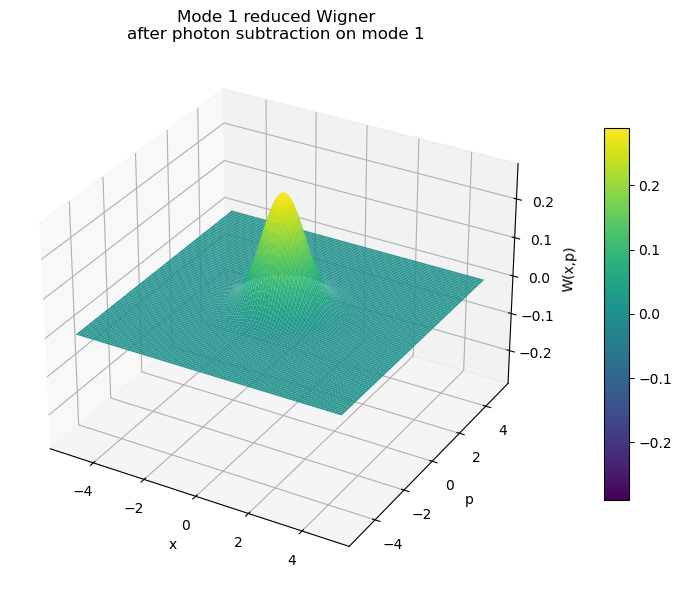

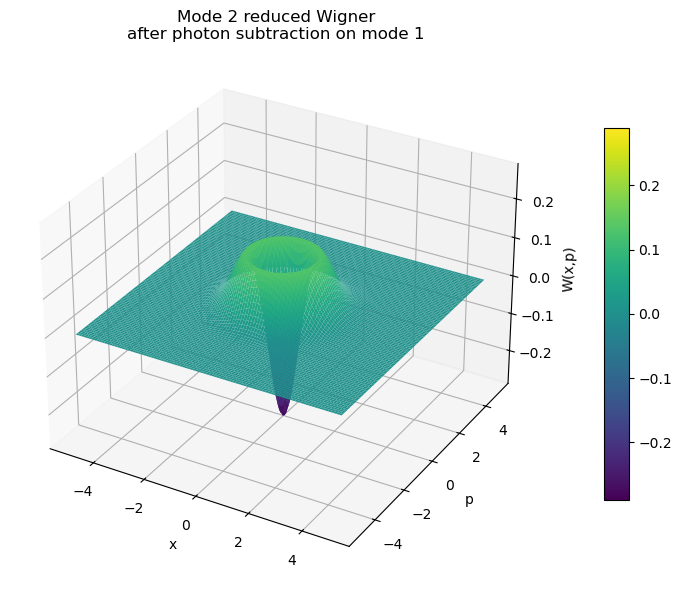

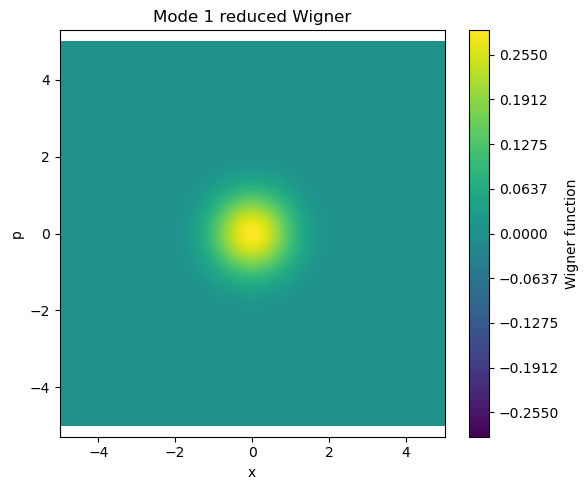

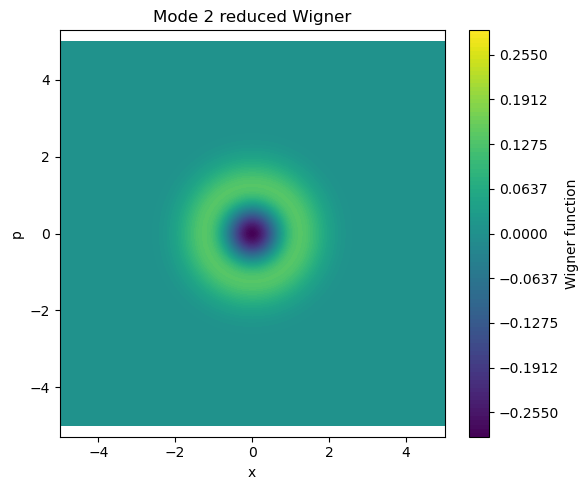


Summary
g = 0.3
s = 1.047
r = -0.022964465944199867
N = 50

Mode 1:
K_ex(x) = -0.005282421045806895
K_ex(p) = -0.006333901118561691

Mode 2:
K_ex(x) = -1.3136514621998878
K_ex(p) = -1.3116675469952221

Node 2 fidelity with pure single photon
F(rho2, |1>) = 0.9535042587235627

Node 2 fidelity with squeezed single photon
s1_target = 3.0
F(rho2, S(r1)|1>) = 0.6192111981818681

Best squeezed single photon fidelity scan
s1 scan range = (0.1, 10.0)
best s1 = 0.9954773869346734
max F(rho2, S(r)|1>) = 0.9535003660049062


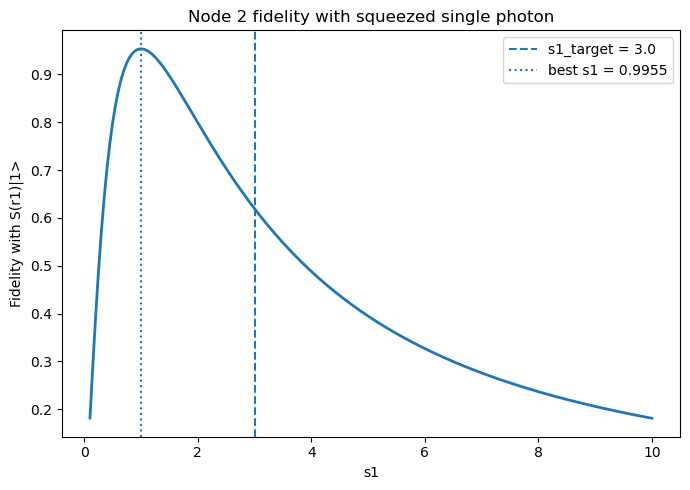

In [112]:
# pip install qutip numpy matplotlib

import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401


# ============================================================
# Parameters
# ============================================================

N = 50
g = 0.3
#s is 1dB
s = 1.047

#dB scale
s_db = 10 * np.log10(s)
print(f"s = {s} ({s_db:.1f} dB)")
# QuTiP squeeze parameter
# target roughly: Var(x) large, Var(p) small
#
# x = (a + a^\dagger)/sqrt(2)
# p = (a - a^\dagger)/(i sqrt(2))
#
# vacuum variance: Var(x)=Var(p)=1/2
#
# With this convention:
# squeeze(N, r) gives roughly
# Var(x) = exp(-2r)/2
# Var(p) = exp(+2r)/2
#
# Here r = -0.5 log(s)
# Therefore
# Var(x) = s/2
# Var(p) = 1/(2s)
r = -0.5 * np.log(s)

xmax = 5.0
n_grid = 201


# ============================================================
# Basic single-mode operators
# ============================================================

a = qt.destroy(N)
I = qt.qeye(N)

x = (a + a.dag()) / np.sqrt(2)
p = (a - a.dag()) / (1j * np.sqrt(2))


# ============================================================
# Two-mode operators
# ============================================================

a1 = qt.tensor(a, I)
a2 = qt.tensor(I, a)

x1 = qt.tensor(x, I)
x2 = qt.tensor(I, x)

p1 = qt.tensor(p, I)
p2 = qt.tensor(I, p)


# ============================================================
# Helper functions
# ============================================================

def real_trace(O):
    """
    Return real part of trace.
    """
    return np.real(O.tr())


def expectation(rho, O):
    """
    Return <O> = Tr(rho O).
    """
    return np.real((rho * O).tr())


def central_moment(rho, q, order):
    """
    Compute <(q - <q>)^order>.
    Here q is a single-mode operator and rho is a single-mode density matrix.
    """

    mu = expectation(rho, q)

    Iq = qt.qeye(q.dims[0][0])
    q_centered = q - mu * Iq

    return expectation(rho, q_centered ** order)


def variance(rho, q):
    """
    Compute Var(q) = <(q - <q>)^2>.
    """
    return central_moment(rho, q, 2)


def fourth_central_moment(rho, q):
    """
    Compute <(q - <q>)^4>.
    """
    return central_moment(rho, q, 4)


def excess_kurtosis(rho, q):
    """
    Compute excess kurtosis:

        K_ex(q) = <(q - <q>)^4> / Var(q)^2 - 3

    Gaussian distribution gives K_ex = 0.
    Single-photon-like distributions often give negative K_ex.
    """

    var = variance(rho, q)
    fourth = fourth_central_moment(rho, q)

    if np.abs(var) < 1e-14:
        return np.nan

    return fourth / (var ** 2) - 3


def print_quadrature_moments(label, rho):
    """
    Print mean, variance, fourth central moment, and excess kurtosis
    for x and p quadratures.
    """

    mx = expectation(rho, x)
    mp = expectation(rho, p)

    vx = variance(rho, x)
    vp = variance(rho, p)

    m4x = fourth_central_moment(rho, x)
    m4p = fourth_central_moment(rho, p)

    kx = excess_kurtosis(rho, x)
    kp = excess_kurtosis(rho, p)

    print()
    print("============================================================")
    print(label)
    print("============================================================")
    print("<x>      =", mx)
    print("<p>      =", mp)
    print("Var(x)   =", vx)
    print("Var(p)   =", vp)
    print("mu4(x)   =", m4x)
    print("mu4(p)   =", m4p)
    print("K_ex(x)  =", kx)
    print("K_ex(p)  =", kp)


def plot_wigner_3d_same_scale(X, P, W, title, Wmin, Wmax):
    """
    Plot 3D Wigner function with fixed z-scale and color scale.
    """

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")

    surf = ax.plot_surface(
        X,
        P,
        W,
        rstride=2,
        cstride=2,
        linewidth=0,
        antialiased=True,
        cmap="viridis",
        vmin=Wmin,
        vmax=Wmax,
    )

    ax.set_xlabel("x")
    ax.set_ylabel("p")
    ax.set_zlabel("W(x,p)")
    ax.set_zlim(Wmin, Wmax)
    ax.set_title(title)

    fig.colorbar(surf, shrink=0.7, aspect=15, pad=0.08)
    plt.tight_layout()
    plt.show()


def plot_wigner_contour_same_scale(X, P, W, title, Wmin, Wmax):
    """
    Plot contour Wigner function with fixed color scale.
    """

    levels = np.linspace(Wmin, Wmax, 101)

    plt.figure(figsize=(6, 5))
    plt.contourf(X, P, W, levels=levels, cmap="viridis")
    plt.colorbar(label="Wigner function")
    plt.xlabel("x")
    plt.ylabel("p")
    plt.title(title)
    plt.axis("equal")
    plt.tight_layout()
    plt.show()


# ============================================================
# 1. Two-node graph state
# ============================================================

vac = qt.basis(N, 0)
S = qt.squeeze(N, r)

psi_in = qt.tensor(S * vac, S * vac)

# CV CZ gate:
#
# U_CZ = exp(i g x1 x2)
#
# This gives Heisenberg transformation roughly:
# p1 -> p1 + g x2
# p2 -> p2 + g x1
U_CZ = (1j * g * x1 * x2).expm()

psi_graph = U_CZ * psi_in
rho_graph = psi_graph.proj()


# ============================================================
# 2. Photon subtraction on mode 1
# ============================================================

rho_sub_unnorm = a1 * rho_graph * a1.dag()

P_sub = np.real(rho_sub_unnorm.tr())

if P_sub < 1e-14:
     raise ValueError("Photon subtraction probability is too small. Increase g or squeezing.")

rho_sub = rho_sub_unnorm / P_sub

print("Photon subtraction probability =", P_sub)
print("Trace of rho_sub =", np.real(rho_sub.tr()))


# ============================================================
# 3. Reduced states
# ============================================================

rho1 = rho_sub.ptrace(0)
rho2 = rho_sub.ptrace(1)

rho1 = rho1 / rho1.tr()
rho2 = rho2 / rho2.tr()

print()
print("Reduced state check")
print("||rho1 - rho2|| =", (rho1 - rho2).norm())
print("Purity rho1 =", np.real((rho1 * rho1).tr()))
print("Purity rho2 =", np.real((rho2 * rho2).tr()))


# ============================================================
# 4. Excess kurtosis of reduced states
# ============================================================

print_quadrature_moments(
    "Mode 1 reduced state after photon subtraction on mode 1",
    rho1,
)

print_quadrature_moments(
    "Mode 2 reduced state after photon subtraction on mode 1",
    rho2,
)


# ============================================================
# 5. Wigner functions
# ============================================================

xvec = np.linspace(-xmax, xmax, n_grid)
pvec = np.linspace(-xmax, xmax, n_grid)

X, P = np.meshgrid(xvec, pvec)

W1 = qt.wigner(rho1, xvec, pvec)
W2 = qt.wigner(rho2, xvec, pvec)

ix0 = np.argmin(np.abs(xvec))
ip0 = np.argmin(np.abs(pvec))

print()
print("============================================================")
print("Wigner function values")
print("============================================================")

print()
print("Mode 1:")
print("W1(0,0) =", W1[ip0, ix0])
print("min W1  =", W1.min())
print("max W1  =", W1.max())

print()
print("Mode 2:")
print("W2(0,0) =", W2[ip0, ix0])
print("min W2  =", W2.min())
print("max W2  =", W2.max())


# ============================================================
# 6. Plot with same z scale and same color scale
# ============================================================

Wmin = min(W1.min(), W2.min())
Wmax = max(W1.max(), W2.max())

plot_wigner_3d_same_scale(
    X,
    P,
    W1,
    "Mode 1 reduced Wigner\nafter photon subtraction on mode 1",
    Wmin,
    Wmax,
)

plot_wigner_3d_same_scale(
    X,
    P,
    W2,
    "Mode 2 reduced Wigner\nafter photon subtraction on mode 1",
    Wmin,
    Wmax,
)


# ============================================================
# 7. Same-scale contour plots
# ============================================================

plot_wigner_contour_same_scale(
    X,
    P,
    W1,
    "Mode 1 reduced Wigner",
    Wmin,
    Wmax,
)

plot_wigner_contour_same_scale(
    X,
    P,
    W2,
    "Mode 2 reduced Wigner",
    Wmin,
    Wmax,
)


# ============================================================
# 8. Short summary
# ============================================================

Kx1 = excess_kurtosis(rho1, x)
Kp1 = excess_kurtosis(rho1, p)

Kx2 = excess_kurtosis(rho2, x)
Kp2 = excess_kurtosis(rho2, p)

print()
print("============================================================")
print("Summary")
print("============================================================")
print("g =", g)
print("s =", s)
print("r =", r)
print("N =", N)
print()
print("Mode 1:")
print("K_ex(x) =", Kx1)
print("K_ex(p) =", Kp1)
print()
print("Mode 2:")
print("K_ex(x) =", Kx2)
print("K_ex(p) =", Kp2)

# ============================================================
# 9. Fidelity with pure single photon and squeezed single photon
# ============================================================

def fidelity_with_pure_ket(rho, ket):
    """
    Fidelity between a density matrix rho and a pure target state |psi>.

        F = <psi| rho |psi>

    This is the usual fidelity when one of the two states is pure.
    """

    ket = ket.unit()
    proj = ket.proj()

    F = np.real((rho * proj).tr())

    return F


def squeezed_single_photon_ket(N, s1):
    """
    Construct squeezed single photon state:

        |psi_s1> = S(r1)|1>

    using the same squeezing convention as the main code:

        r1 = -0.5 log(s1)

    Therefore roughly:

        Var(x) = s1 * 3/2
        Var(p) = (1/s1) * 3/2

    for the squeezed single photon.

    s1 = 1 gives the ordinary pure single photon |1>.
    """

    if s1 <= 0:
        raise ValueError("s1 must be positive.")

    r1 = -0.5 * np.log(s1)

    S1 = qt.squeeze(N, r1)
    ket1 = qt.basis(N, 1)

    psi_squeezed_1 = S1 * ket1
    psi_squeezed_1 = psi_squeezed_1.unit()

    return psi_squeezed_1


# ------------------------------------------------------------
# 9-1. Fidelity between node 2 and pure single photon |1>
# ------------------------------------------------------------

ket1 = qt.basis(N, 1)

F_node2_single_photon = fidelity_with_pure_ket(rho2, ket1)

print()
print("============================================================")
print("Node 2 fidelity with pure single photon")
print("============================================================")
print("F(rho2, |1>) =", F_node2_single_photon)


# ------------------------------------------------------------
# 9-2. Fidelity between node 2 and one chosen squeezed single photon
# ------------------------------------------------------------

# 원하는 squeezing parameter를 여기서 바꾸면 됨.
# s1 = 1이면 ordinary single photon |1>
# s1 > 1이면 x 방향 anti-squeezed, p 방향 squeezed single photon
s1_target = 3.0

ket_squeezed_1_target = squeezed_single_photon_ket(N, s1_target)

F_node2_squeezed_single_photon_target = fidelity_with_pure_ket(
    rho2,
    ket_squeezed_1_target,
)

print()
print("============================================================")
print("Node 2 fidelity with squeezed single photon")
print("============================================================")
print("s1_target =", s1_target)
print("F(rho2, S(r1)|1>) =", F_node2_squeezed_single_photon_target)


# ------------------------------------------------------------
# 9-3. Fidelity graph versus squeezed-single-photon parameter s1
# ------------------------------------------------------------

s1_min = 0.1
s1_max = 10.0
n_s1 = 200

s1_values = np.linspace(s1_min, s1_max, n_s1)

F_squeezed_single_photon_values = []

for_s1_error_check = False

for s1_val in s1_values:
    ket_squeezed_1 = squeezed_single_photon_ket(N, s1_val)

    F_val = fidelity_with_pure_ket(
        rho2,
        ket_squeezed_1,
    )

    F_squeezed_single_photon_values.append(F_val)

F_squeezed_single_photon_values = np.array(F_squeezed_single_photon_values)

idx_best = np.argmax(F_squeezed_single_photon_values)

s1_best = s1_values[idx_best]
F_best = F_squeezed_single_photon_values[idx_best]

print()
print("============================================================")
print("Best squeezed single photon fidelity scan")
print("============================================================")
print("s1 scan range =", (s1_min, s1_max))
print("best s1 =", s1_best)
print("max F(rho2, S(r)|1>) =", F_best)


plt.figure(figsize=(7, 5))
plt.plot(
    s1_values,
    F_squeezed_single_photon_values,
    linewidth=2,
)

plt.axvline(
    s1_target,
    linestyle="--",
    linewidth=1.5,
    label=f"s1_target = {s1_target}",
)

plt.axvline(
    s1_best,
    linestyle=":",
    linewidth=1.5,
    label=f"best s1 = {s1_best:.4f}",
)

plt.xlabel("s1")
plt.ylabel("Fidelity with S(r1)|1>")
plt.title("Node 2 fidelity with squeezed single photon")
plt.legend()
plt.tight_layout()
plt.show()